In [44]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'utils')))
import os
import pickle
import itertools
import numpy as np
import numpy.ma as ma
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from models import MLP

In [45]:
USE_ENSEMBLES          = True
SEEDS                  = [42, 43, 44, 45, 46]
# R2_THRESHOLD           = 0.1    # min mean R² for permutation importance
# CONSISTENCY_THRESHOLD  = 0.05   # lower threshold — include more neurons in consistency
N_PERM_REPEATS         = 5

# Set to False to skip recomputation and load saved results from disk instead.
RUN_EVAL        = False
RUN_IMPORTANCE  = True
RUN_CONSISTENCY = False

if USE_ENSEMBLES:
    R2_THRESHOLD           = 0.1    # min mean R² for permutation importance
    CONSISTENCY_THRESHOLD  = 0.1   # lower threshold — include more ensembles in consistency
else:
    R2_THRESHOLD           = 0.1    # min mean R² for permutation importance
    CONSISTENCY_THRESHOLD  = 0.1   # lower threshold — include more neurons in consistency

mode_str    = "ensembles" if USE_ENSEMBLES else "spikes"
prefix_name = "E" if USE_ENSEMBLES else "U"
models_root = f"../models/mlps/{mode_str}"
splits_dir  = "../splits"
output_dir  = f"../outputs/mlps/{mode_str}_multiseed"
cache_path  = f"../outputs/session_dataset_{mode_str}.pkl"
os.makedirs(output_dir, exist_ok=True)

unit_label    = "ensemble" if USE_ENSEMBLES else "neuron"
unit_label_pl = unit_label + "s"

print(f"mode={mode_str}, seeds={SEEDS}")
print(f"RUN_EVAL={RUN_EVAL}, RUN_IMPORTANCE={RUN_IMPORTANCE}, RUN_CONSISTENCY={RUN_CONSISTENCY}")
print(f"R2_THRESHOLD={R2_THRESHOLD}, CONSISTENCY_THRESHOLD={CONSISTENCY_THRESHOLD}")

mode=ensembles, seeds=[42, 43, 44, 45, 46]
RUN_EVAL=False, RUN_IMPORTANCE=True, RUN_CONSISTENCY=False
R2_THRESHOLD=0.1, CONSISTENCY_THRESHOLD=0.1


In [46]:
# ── Load raw data ──────────────────────────────────────────────────────────
# if any([RUN_EVAL, RUN_IMPORTANCE, RUN_CONSISTENCY]) and not os.path.exists(cache_path):
base = "../outputs/glm_input_data/"

beh_vals = np.load(os.path.join(base, "behavior_glm_input.npy"), allow_pickle=True)
beh_idx  = np.load(os.path.join(base, "behavior_glm_input_index.npy"), allow_pickle=True)
beh_cols = np.load(os.path.join(base, "behavior_glm_input_columns.npy"), allow_pickle=True)

spk_vals = np.load(os.path.join(base, "fr_full.npy"))
spk_idx  = np.load(os.path.join(base, "fr_full_index.npy"), allow_pickle=True)
spk_cols = np.load(os.path.join(base, "fr_full_columns.npy"), allow_pickle=True)

ensembles_values = np.load(os.path.join(base, "ensembles.npy"))

try:
    beh_index = pd.MultiIndex.from_tuples(beh_idx, names=behavior_glm_input.index.names)
except Exception:
    beh_index = pd.Index(beh_idx)

try:
    spk_index = pd.MultiIndex.from_tuples(spk_idx, names=fr_first7.index.names)
except Exception:
    spk_index = pd.Index(spk_idx)

behavior_glm_loaded = pd.DataFrame(beh_vals, index=beh_index, columns=beh_cols)
spikes_loaded       = pd.DataFrame(spk_vals, index=spk_index, columns=spk_cols)

print("behavior_glm_loaded", behavior_glm_loaded.shape)
print("spikes_loaded",       spikes_loaded.shape)
# else:
#     print("Skipping raw data load (cache exists or all RUN_* flags are False)")


behavior_glm_loaded (1333016, 29)
spikes_loaded (1333016, 77)


In [47]:
# ── Preprocessing ──────────────────────────────────────────────────────────
# if any([RUN_EVAL, RUN_IMPORTANCE, RUN_CONSISTENCY]) and not os.path.exists(cache_path):
spikes_loaded.index = pd.MultiIndex.from_tuples(
    spikes_loaded.index.map(lambda t: (t[0], t[1] // 40000 - 1))
)

spikes_unique_trials = set(idx[0] for idx in spikes_loaded.index)
behavior_glm_loaded  = behavior_glm_loaded[
    behavior_glm_loaded.index.map(lambda t: t[0] in spikes_unique_trials)
]

non_nan_rows        = behavior_glm_loaded.index[~behavior_glm_loaded.isna().any(axis=1)]
behavior_glm_loaded = behavior_glm_loaded.loc[non_nan_rows]
spikes_loaded       = spikes_loaded.loc[non_nan_rows]

behavior_glm_loaded = behavior_glm_loaded.drop("track_zone", axis=1)

session_ids = behavior_glm_loaded.index.map(lambda x: x[0]).unique()
print(f"{len(session_ids)} sessions")
# else:
#     print("Skipping preprocessing (cache exists or all RUN_* flags are False)")


29 sessions


In [48]:
non_categorical_cols = [
    'frame_raw_500msMedian',                  # forward_velocity
    'frame_raw_abs_acc_500msMedian',          # forward_acceleration
    'frame_YawPitch_abs_vel_sum_500msMedian', # off_rotation_velocity
    'frame_YawPitch_abs_acc_sum_500msMedian', # off_rotation_acceleration
    'head_angle_vel',
    'head_angle',
    'movement_energy_smooth5',                # movement_energy
]

categorical_variables = [
    'track_zone_int',
    'cue_visible',
    'upcoming_choice',
    'reward_window',
    'lick_detected',
]

zone_onehot_cols = []
for col in categorical_variables:
    col_vals = sorted(behavior_glm_loaded[col].dropna().unique().astype(int))
    for v in col_vals:
        behavior_glm_loaded[f'{col}_{v}'] = (behavior_glm_loaded[col] == v).astype(float)
    if len(col_vals) == 2:
        zone_onehot_cols.append(f'{col}_{col_vals[-1]}')
    else:
        zone_onehot_cols.extend([f'{col}_{v}' for v in col_vals])

all_feat_cols = non_categorical_cols + zone_onehot_cols
print(f"{len(all_feat_cols)} input features ({len(non_categorical_cols)} non-categorical + {len(zone_onehot_cols)} categorical)")

26 input features (7 non-categorical + 19 categorical)


In [49]:
# ── Build / load session dataset (cached on disk) ──────────────────────────
if os.path.exists(cache_path):
    with open(cache_path, 'rb') as f:
        session_dataset_singles = pickle.load(f)
    session_ids = pd.Index(list(session_dataset_singles.keys()))
    print(f"Loaded dataset from cache: {cache_path}")
elif not any([RUN_EVAL, RUN_IMPORTANCE, RUN_CONSISTENCY]):
    raise FileNotFoundError(
        f"Cache not found: {cache_path}\n"
        "Set at least one RUN_* flag to True to build the cache first."
    )
else:
    session_dataset_singles = {}
    for session_id in session_ids:
        session_mask   = behavior_glm_loaded.index.map(lambda x: x[0]) == session_id
        beh            = behavior_glm_loaded[session_mask]
        spikes_session = spikes_loaded[session_mask]

        for col in non_categorical_cols:
            if col in beh.columns:
                beh.loc[:, col] = beh[col].astype(float)
                mean_val = beh[col].mean()
                std_val  = beh[col].std() + 1e-8
                if std_val != 0:
                    beh.loc[:, col] = (beh[col] - mean_val) / std_val

        spikes_session = spikes_session.astype(float)
        if USE_ENSEMBLES:
            spikes_values = spikes_session.values
            new_spikes_session = pd.DataFrame(index=spikes_session.index)
            for i in range(ensembles_values.shape[1]):
                new_spikes_session[f'ensemble_{i}'] = spikes_values @ ensembles_values[:, i]
            spikes_session = new_spikes_session

        label_stds = []
        for col in spikes_session.columns:
            mean_val = spikes_session[col].mean()
            std_val  = spikes_session[col].std() + 1e-8
            label_stds.append(std_val)
            if std_val != 0:
                spikes_session[col] = (spikes_session[col] - mean_val) / std_val

        data_by_trial, labels_by_trial = {}, {}
        for trial_id in beh["trial_id"].unique():
            trial_mask                = beh["trial_id"] == trial_id
            data_by_trial[trial_id]   = beh.loc[trial_mask, all_feat_cols].values.astype(np.float16)
            labels_by_trial[trial_id] = spikes_session.loc[trial_mask].values.astype(np.float16)

        session_dataset_singles[session_id] = {
            "data":       data_by_trial,
            "labels":     labels_by_trial,
            "label_stds": label_stds,
        }

    with open(cache_path, 'wb') as f:
        pickle.dump(session_dataset_singles, f)
    print(f"Dataset built and cached to {cache_path}")

Loaded dataset from cache: ./outputs/session_dataset_ensembles.pkl


In [50]:
# ── Model config ────────────────────────────────────────────────────────────
input_size        = len(all_feat_cols)
hidden_size       = 64
num_hidden_layers = 2
output_size       = 1
num_sessions      = len(session_ids)
num_neurons       = len(next(iter(session_dataset_singles.values()))['label_stds'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"input_size={input_size}, sessions={num_sessions}, {unit_label_pl}={num_neurons}, device={device}")


input_size=26, sessions=29, ensembles=23, device=cuda


In [51]:
if RUN_EVAL:
    # Results: (n_seeds, n_sessions, n_neurons)
    all_mse = np.full((len(SEEDS), num_sessions, num_neurons), np.nan)
    all_r2  = np.full((len(SEEDS), num_sessions, num_neurons), np.nan)

    for seed_idx, seed in enumerate(SEEDS):
        split_path = os.path.join(splits_dir, f"split_seed{seed}.npy")
        test_indices_by_session = np.load(split_path, allow_pickle=True).item()
        models_dir = os.path.join(models_root, f"seed{seed}")

        for test_idx, test_session in enumerate(session_ids):
            session_data   = session_dataset_singles[test_session]["data"]
            session_labels = session_dataset_singles[test_session]["labels"]
            test_idx_      = test_indices_by_session[test_session]

            test_data = torch.tensor(
                np.concatenate([session_data[idx]   for idx in test_idx_], axis=0),
                dtype=torch.float32).to(device)
            test_labels_np = np.concatenate(
                [session_labels[idx] for idx in test_idx_], axis=0)

            for neuron_idx in range(num_neurons):
                mpath = os.path.join(models_dir, f"session_{test_idx:02d}_neuron_{neuron_idx:02d}.pt")
                if not os.path.exists(mpath):
                    continue
                model = MLP(input_size, hidden_size, num_hidden_layers, output_size).to(device)
                model.load_state_dict(torch.load(mpath, map_location=device))
                model.eval()
                with torch.no_grad():
                    _, preds = model(test_data)
                    preds_np = preds.squeeze().cpu().numpy()
                actual = test_labels_np[:, neuron_idx]
                all_mse[seed_idx, test_idx, neuron_idx] = mean_squared_error(actual, preds_np)
                if np.var(actual) > 1e-8:  # avoid R² errors when variance is zero
                    all_r2[seed_idx,  test_idx, neuron_idx] = r2_score(actual, preds_np)
                del model

            del test_data, test_labels_np
            torch.cuda.empty_cache()

        print(f"Seed {seed} done.")

    np.save(os.path.join(output_dir, "all_mse.npy"), all_mse)
    np.save(os.path.join(output_dir, "all_r2.npy"),  all_r2)
    print("Saved all_mse.npy and all_r2.npy")
else:
    print("Skipping eval (RUN_EVAL=False) — load from disk in next cell.")

Skipping eval (RUN_EVAL=False) — load from disk in next cell.


In [52]:
# ── Reload saved metrics (skip eval loop above if already run) ─────────────
all_mse = np.load(os.path.join(output_dir, "all_mse.npy"))
all_r2  = np.load(os.path.join(output_dir, "all_r2.npy"))

In [53]:
# ── Mask silent neurons + compute seed-averaged metrics ────────────────────
# mask = np.zeros((num_sessions, num_neurons), dtype=bool)
# for i, session_id in enumerate(session_ids):
#     for j, std in enumerate(session_dataset_singles[session_id]["label_stds"]):
#         if std < 1e-3:
#             mask[i, j] = True

mask_3d = np.isnan(all_r2)
mask = np.any(mask_3d, axis=0)  # (sessions, neurons) --- True for any neuron/session with NaN R²


In [54]:
all_r2_masked = all_r2.copy().astype(float)
all_mse_masked = all_mse.copy().astype(float)

# Expand mask to match (seeds, sessions, neurons)
all_r2_masked[mask_3d] = np.nan
all_mse_masked[mask_3d] = np.nan

print(f"NaNs introduced: {np.isnan(all_r2_masked).sum()}")

# Aggregate across seeds (axis=0)
with np.errstate(all='ignore'):
    mean_r2    = np.nanmean(all_r2_masked,   axis=0)   # (29, 77)
    std_r2     = np.nanstd(all_r2_masked,    axis=0)
    median_r2  = np.nanmedian(all_r2_masked, axis=0)
    mean_mse   = np.nanmean(all_mse_masked,  axis=0)
    std_mse    = np.nanstd(all_mse_masked,   axis=0)
    median_mse = np.nanmedian(all_mse_masked, axis=0)

# Report — now mask is already applied so no need to index with ~mask
print(f"Valid pairs: {(~mask).sum()}")
print(f"Mean R²   (seed-avg): {np.nanmean(mean_r2[~mask]):.3f} ± {np.nanstd(mean_r2[~mask]):.3f}")
print(f"Median R² (seed-avg): {np.nanmedian(median_r2[~mask]):.3f} ± {np.nanstd(median_r2[~mask]):.3f}")
print(f"Mean MSE  (seed-avg): {np.nanmean(mean_mse[~mask]):.3f} ± {np.nanstd(mean_mse[~mask]):.3f}")
print(f"Median MSE(seed-avg): {np.nanmedian(median_mse[~mask]):.3f} ± {np.nanstd(median_mse[~mask]):.3f}")

NaNs introduced: 0
Valid pairs: 667
Mean R²   (seed-avg): 0.032 ± 0.075
Median R² (seed-avg): 0.023 ± 0.079
Mean MSE  (seed-avg): 0.970 ± 0.092
Median MSE(seed-avg): 0.965 ± 0.097


In [55]:
flat_r2 = mean_r2[~mask]
print(f"Catastrophic pairs (R² < -1000): {(flat_r2 < -1000).sum()}")
print(f"Median of valid pairs: {np.nanmedian(flat_r2):.3f}")
print(f"Without catastrophic: {np.nanmean(flat_r2[flat_r2 > -1000]):.3f}")

Catastrophic pairs (R² < -1000): 0
Median of valid pairs: 0.022
Without catastrophic: 0.032


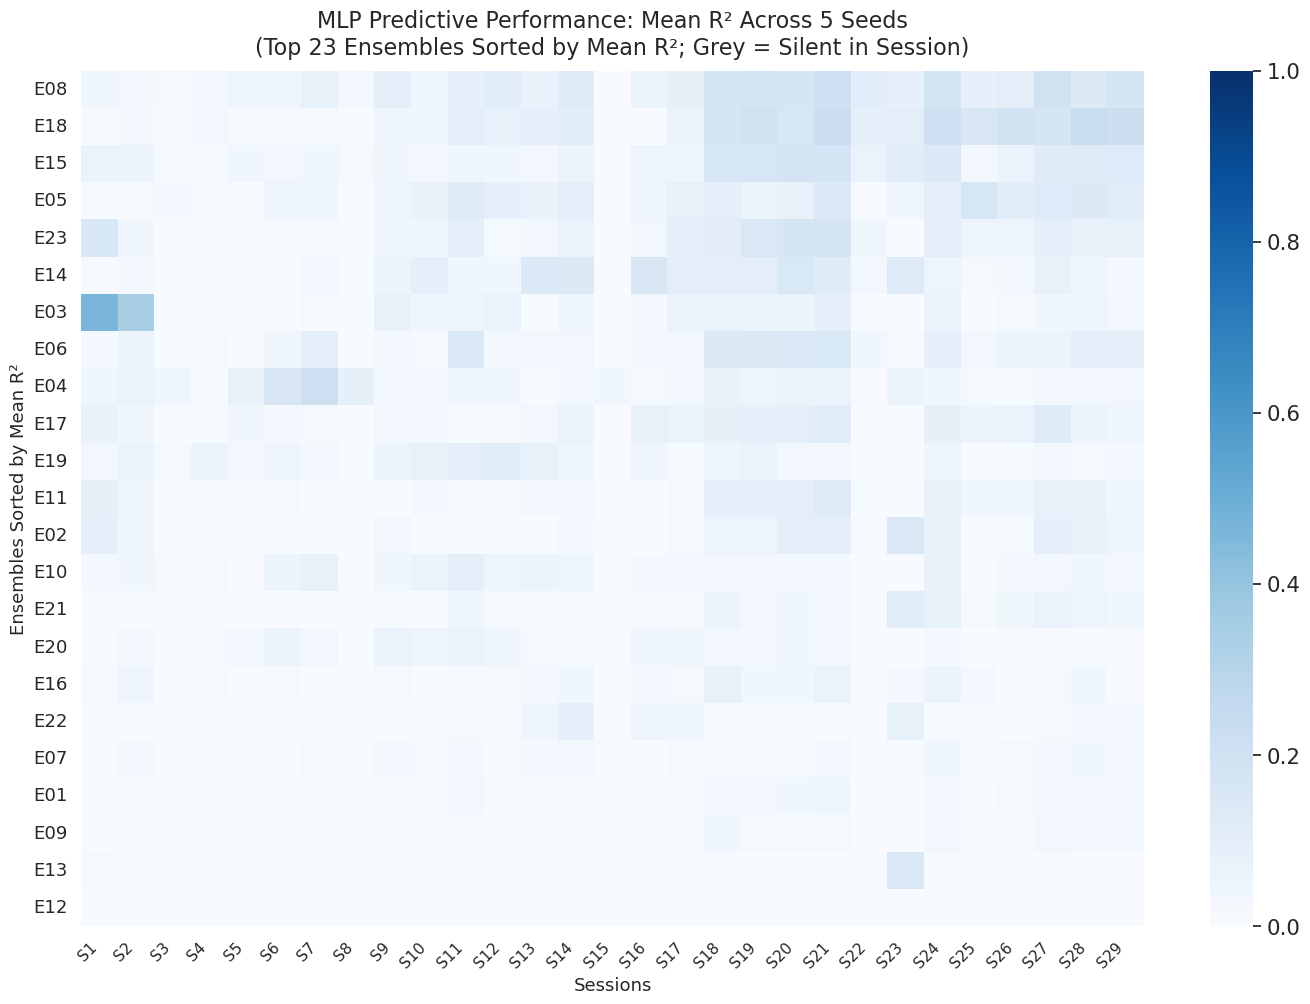

In [56]:
# ── R² heatmap: mean across seeds (blue scale) ────────────────────────────
valid_n = ~np.all(mask, axis=0)
valid_s = ~np.all(mask, axis=1)
n_vn, n_vs = valid_n.sum(), valid_s.sum()

r2_clipped = np.clip(mean_r2, 0.0, 1.0)
r2_filt    = r2_clipped[np.ix_(valid_s, valid_n)]
std_filt   = std_r2[np.ix_(valid_s, valid_n)]
mask_filt  = mask[np.ix_(valid_s, valid_n)]

neuron_mean_filt  = ma.array(r2_filt, mask=mask_filt).mean(axis=0).filled(np.nan)
neuron_order_filt = np.argsort(neuron_mean_filt)[::-1]

valid_n_idx = np.where(valid_n)[0]
valid_s_idx = np.where(valid_s)[0]

N_SHOW = min(30, n_vn)
show_idx      = neuron_order_filt[:N_SHOW]
sorted_n_show = valid_n_idx[show_idx]

# Store for the std heatmap cell near the consistency section.
r2_show_data    = r2_filt[:, show_idx].T
std_show_data   = std_filt[:, show_idx].T
mask_show_data  = mask_filt[:, show_idx].T
r2_ytick_labels = [f"{prefix_name}{sorted_n_show[i]+1:02d}" for i in range(N_SHOW)]
r2_xtick_labels = [f"S{j+1}" for j in valid_s_idx]

cell_h = 0.45
cell_w = 0.50
fig_h  = max(8, N_SHOW * cell_h)
fig_w  = max(14, n_vs * cell_w)

NO_DATA_COLOR = '#bbbbbb'   # grey — clearly outside the Blues colormap range

cmap_r2 = plt.cm.Blues.copy()
cmap_r2.set_bad(color=NO_DATA_COLOR)
r2_plot = r2_show_data.astype(float)
r2_plot[mask_show_data] = np.nan

sns.set_theme(style="white", font_scale=1.4)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(r2_plot, cmap=cmap_r2, vmin=0, vmax=1,
            xticklabels=r2_xtick_labels, yticklabels=r2_ytick_labels, ax=ax)
for (i, j) in zip(*np.where(mask_show_data)):
    ax.add_patch(plt.Rectangle([j, i], 1, 1, fill=True, facecolor=NO_DATA_COLOR,
                                hatch='////', edgecolor='#888888', lw=0.5, zorder=2))
ax.set_yticklabels(ax.get_yticklabels(), fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=45, ha='right')
ax.set_title(f'MLP Predictive Performance: Mean R² Across {len(SEEDS)} Seeds\n'
             f'(Top {N_SHOW} {unit_label_pl.capitalize()} Sorted by Mean R²; Grey = Silent in Session)', fontsize=16, pad=12)
ax.set_xlabel('Sessions', fontsize=13)
ax.set_ylabel(f'{unit_label_pl.capitalize()} Sorted by Mean R²', fontsize=13)
plt.tight_layout()
plt.show()
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

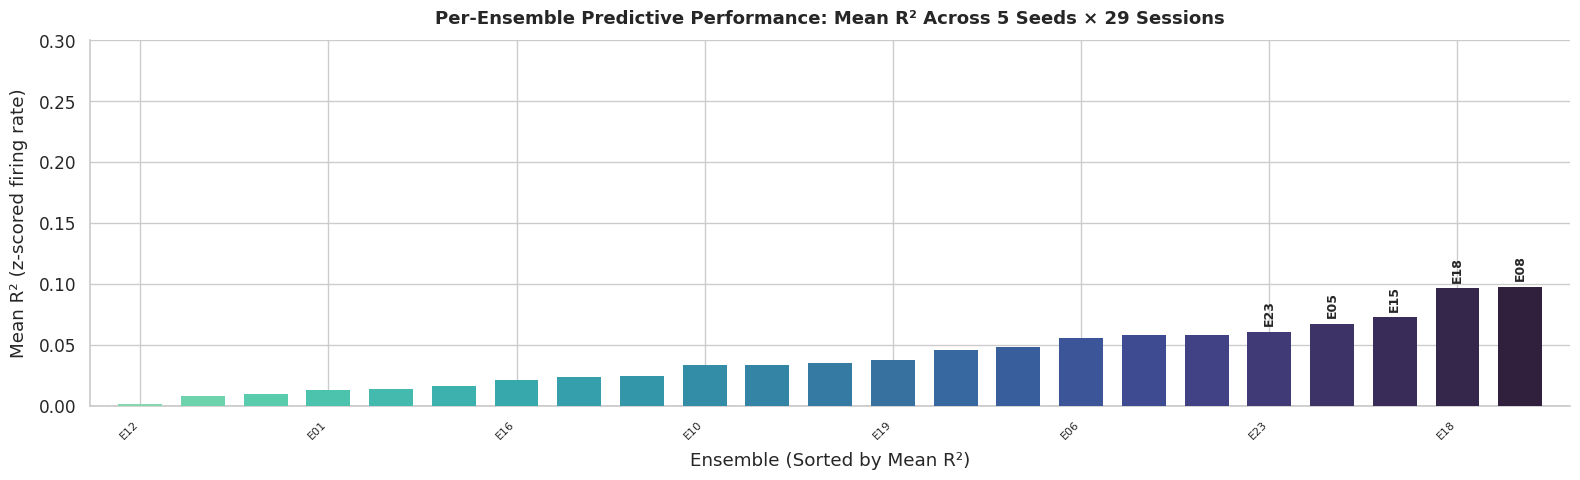

In [57]:
# ── Per-neuron R² bar chart: mean over seeds × sessions, top-5 labeled ──────
masked_r2      = ma.array(np.clip(mean_r2, 0, 1), mask=mask)
neuron_mean_r2 = masked_r2.mean(axis=0).filled(np.nan)

order   = np.argsort(neuron_mean_r2)          # ascending: worst -> best
x       = np.arange(num_neurons)
labels  = [f"{prefix_name}{i+1:02d}" for i in order]
means_s = neuron_mean_r2[order]

palette = sns.color_palette("mako_r", as_cmap=True)
colors  = palette(np.linspace(0.15, 0.85, num_neurons))

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x, means_s, width=0.7, color=colors, zorder=3, linewidth=0)
ax.axhline(0, color='firebrick', linestyle='--', linewidth=1)

# Label top-5 neurons by name
top5_pos = list(range(num_neurons - 5, num_neurons))
for pos in top5_pos:
    ax.text(pos, means_s[pos] + 0.005, labels[pos],
            ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=90)

ax.set_xticks(x[::3])
ax.set_xticklabels(labels[::3], rotation=45, ha="right", fontsize=8)
ax.set_xlabel(f"{unit_label.capitalize()} (Sorted by Mean R²)", labelpad=8)
ax.set_ylabel("Mean R² (z-scored firing rate)", labelpad=8)
ax.set_title(f"Per-{unit_label.capitalize()} Predictive Performance: Mean R² Across {len(SEEDS)} Seeds × {num_sessions} Sessions",
             fontsize=13, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.set_xlim(-0.8, num_neurons - 0.2)
ax.set_ylim(0, 0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

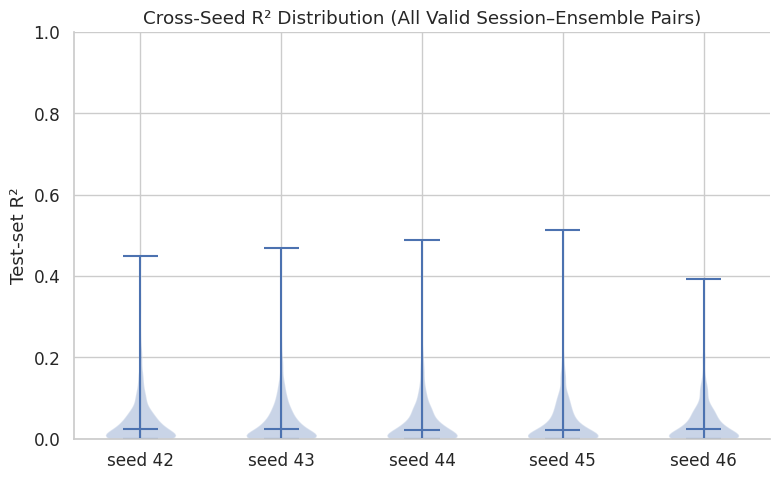

In [58]:
# ── Per-seed R² violin ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
data_per_seed = [np.clip(all_r2[s_idx][~mask], 0, 1) for s_idx in range(len(SEEDS))]
ax.violinplot(data_per_seed, positions=range(len(SEEDS)), showmedians=True)
ax.set_xticks(range(len(SEEDS)))
ax.set_xticklabels([f"seed {s}" for s in SEEDS])
ax.set_ylabel("Test-set R²")
ax.set_title(f"Cross-Seed R² Distribution (All Valid Session–{unit_label.capitalize()} Pairs)")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# ── Variance vs MSE scatter (seed-averaged) ────────────────────────────────
_test_idx = np.load(os.path.join(splits_dir, f"split_seed{SEEDS[0]}.npy"), allow_pickle=True).item()

variance, mse_vals = [], []

for session_id in session_ids:
    test_idx_num = list(session_ids).index(session_id)
    session_data   = session_dataset_singles[session_id]["data"]
    session_labels = session_dataset_singles[session_id]["labels"]
    session_mse    = mean_mse[test_idx_num, :]
    valid_mask     = ~mask[test_idx_num, :]

    test_trial_indices = [int(idx) for idx in _test_idx[session_id]]
    test_trials_data   = {idx: session_data[idx]   for idx in test_trial_indices if idx in session_data}
    test_labels_np     = {idx: session_labels[idx] for idx in test_trial_indices if idx in session_data}

    if not test_trials_data:
        continue

    for neuron_idx in range(num_neurons):
        if not valid_mask[neuron_idx]:
            continue
        actual_variance = np.mean([np.var(test_labels_np[trial_idx][:, neuron_idx])
                                   for trial_idx in test_labels_np])
        variance.append(actual_variance)
        mse_vals.append(session_mse[neuron_idx])

r = np.corrcoef(variance, mse_vals)[0, 1]

plt.figure(figsize=(7, 5))
plt.scatter(variance, mse_vals, alpha=0.15, s=8, color='steelblue')
m, b = np.polyfit(variance, mse_vals, 1)
x_line = np.linspace(min(variance), max(variance), 200)
plt.plot(x_line, m * x_line + b, color='firebrick', linewidth=1.5, label=f'r = {r:.2f}')
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Baseline MSE = 1')
plt.axline((0, 0), slope=1, color='orange', linestyle=':', linewidth=1, label='MSE = Variance')
plt.xlabel('Actual Variance (z-scored FR)')
plt.ylabel('MSE (test set, seed-averaged)')
plt.title('Neuron Firing Rate Variance vs. Prediction MSE')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Variance vs R² scatter (seed-averaged) ───────────────────────────────
variance, r2_vals = [], []

for session_id in session_ids:
    test_idx_num = list(session_ids).index(session_id)
    session_data   = session_dataset_singles[session_id]["data"]
    session_labels = session_dataset_singles[session_id]["labels"]
    session_r2     = np.clip(mean_r2[test_idx_num, :], 0, 1)
    valid_mask     = ~mask[test_idx_num, :]

    test_trial_indices = [int(idx) for idx in _test_idx[session_id]]
    test_trials_data   = {idx: session_data[idx]   for idx in test_trial_indices if idx in session_data}
    test_labels_np     = {idx: session_labels[idx] for idx in test_trial_indices if idx in session_data}

    if not test_trials_data:
        continue

    for neuron_idx in range(num_neurons):
        if not valid_mask[neuron_idx]:
            continue
        actual_variance = np.mean([np.var(test_labels_np[trial_idx][:, neuron_idx])
                                   for trial_idx in test_labels_np])
        variance.append(actual_variance)
        r2_vals.append(session_r2[neuron_idx])

r = np.corrcoef(variance, r2_vals)[0, 1]

plt.figure(figsize=(7, 5))
plt.scatter(variance, r2_vals, alpha=0.15, s=8, color='steelblue')
m, b = np.polyfit(variance, r2_vals, 1)
x_line = np.linspace(min(variance), max(variance), 200)
plt.plot(x_line, m * x_line + b, color='firebrick', linewidth=1.5, label=f'r = {r:.2f}')
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Baseline R² = 1')
plt.xlabel('Actual Variance (z-scored FR)')
plt.ylabel('R² (test set, seed-averaged)')
plt.title('Neuron Firing Rate Variance vs. Prediction R²')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Variance discrepancy (train - test) vs MSE (seed-averaged) ───────────
train_var_all, test_var_all, mse_all = [], [], []

for session_id in session_ids:
    test_idx_num   = list(session_ids).index(session_id)
    session_labels = session_dataset_singles[session_id]["labels"]
    session_mse    = mean_mse[test_idx_num, :]
    valid_mask     = ~mask[test_idx_num, :]

    test_trial_indices  = [int(idx) for idx in _test_idx[session_id]]
    all_trial_ids       = list(session_labels.keys())
    train_trial_indices = [idx for idx in all_trial_ids if idx not in test_trial_indices]

    for neuron_idx in range(num_neurons):
        if not valid_mask[neuron_idx]:
            continue
        train_var = np.mean([np.var(session_labels[idx][:, neuron_idx]) for idx in train_trial_indices])
        test_var  = np.mean([np.var(session_labels[idx][:, neuron_idx]) for idx in test_trial_indices])
        train_var_all.append(train_var)
        test_var_all.append(test_var)
        mse_all.append(session_mse[neuron_idx])

train_var_all = np.array(train_var_all)
test_var_all  = np.array(test_var_all)
mse_all       = np.array(mse_all)
discrepancy   = train_var_all - test_var_all

r_check = np.corrcoef(discrepancy, mse_all)[0, 1]
print(f"Correlation between train-test variance discrepancy and MSE: {r_check:.2f}")

plt.figure(figsize=(6, 5))
plt.scatter(discrepancy, mse_all, alpha=0.15, s=8, color='steelblue')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Train variance - Test variance')
plt.ylabel('MSE (test set, seed-averaged)')
plt.title(f'Variance Discrepancy vs MSE  (r = {r_check:.2f})')
plt.tight_layout()
plt.show()


In [59]:
n_feats = len(all_feat_cols)
if RUN_IMPORTANCE:

    # Filter at neuron level: only neurons whose max R² across sessions meets the bar.
    # Per-session filtering would inflate scores by conditioning on success.
    neuron_max_global = np.nanmax(np.where(mask, np.nan, mean_r2), axis=0)  # (num_neurons,)

    all_importance = np.full((len(SEEDS), num_sessions, num_neurons, n_feats), np.nan)

    valid_neurons = [i for i in range(num_neurons) if  neuron_max_global[i] >= R2_THRESHOLD]

    for seed_idx, seed in enumerate(SEEDS):
        split_path = os.path.join(splits_dir, f"split_seed{seed}.npy")
        test_indices_by_session = np.load(split_path, allow_pickle=True).item()
        models_dir = os.path.join(models_root, f"seed{seed}")

        for test_idx, test_session in enumerate(session_ids):
            session_data   = session_dataset_singles[test_session]["data"]
            session_labels = session_dataset_singles[test_session]["labels"]
            test_idx_      = test_indices_by_session[test_session]

            test_data_np   = np.concatenate([session_data[idx]   for idx in test_idx_], axis=0).astype(np.float32)
            test_labels_np = np.concatenate([session_labels[idx] for idx in test_idx_], axis=0)

            for neuron_idx in valid_neurons:
                if mask[test_idx, neuron_idx]:
                    print(f"Skipping seed {seed}, session {test_idx}, {unit_label} {neuron_idx} (masked)")
                    continue
                # if all_r2[seed_idx, test_idx, neuron_idx] < 0.1:
                #     continue
                mpath = os.path.join(models_dir, f"session_{test_idx:02d}_neuron_{neuron_idx:02d}.pt")
                if not os.path.exists(mpath):
                    continue

                model = MLP(input_size, hidden_size, num_hidden_layers, output_size).to(device)
                model.load_state_dict(torch.load(mpath, map_location=device))
                model.eval()

                with torch.no_grad():
                    _, preds = model(torch.tensor(test_data_np, dtype=torch.float32).to(device))
                    baseline_r2 = all_r2[seed_idx, test_idx, neuron_idx]

                for feat_idx in range(n_feats):
                    r2_permuted = []
                    for _ in range(N_PERM_REPEATS):
                        permuted = test_data_np.copy()
                        np.random.shuffle(permuted[:, feat_idx])
                        with torch.no_grad():
                            _, pp = model(torch.tensor(permuted, dtype=torch.float32).to(device))
                            r2_permuted.append(r2_score(test_labels_np[:, neuron_idx],
                                                        pp.squeeze().cpu().numpy()))
                    all_importance[seed_idx, test_idx, neuron_idx, feat_idx] = (
                        baseline_r2 - np.mean(r2_permuted)
                    )

                del model
                torch.cuda.empty_cache()

            del test_data_np, test_labels_np

        print(f"Seed {seed} importance done.")

    # nanmedian is more robust to outlier seeds than nanmean
    with np.errstate(all='ignore'):
        importance_matrix = np.nanmedian(all_importance, axis=0)
    np.save(os.path.join(output_dir, "importance_matrix.npy"), importance_matrix)
    print("Saved importance_matrix.npy")
else:
    print("Skipping importance (RUN_IMPORTANCE=False) — load from disk in next cell.")

Seed 42 importance done.
Seed 43 importance done.
Seed 44 importance done.
Seed 45 importance done.
Seed 46 importance done.
Saved importance_matrix.npy


/tmp/ipykernel_619175/1477787584.py:65: RuntimeWarning: All-NaN slice encountered
  importance_matrix = np.nanmedian(all_importance, axis=0)


In [83]:
for seed_idx, seed in enumerate(SEEDS):
    split_path = os.path.join(splits_dir, f"split_seed{seed}.npy")
    test_indices_by_session = np.load(split_path, allow_pickle=True).item()
    models_dir = os.path.join(models_root, f"seed{seed}")

    for test_idx, test_session in enumerate(session_ids):
        session_data   = session_dataset_singles[test_session]["data"]
        session_labels = session_dataset_singles[test_session]["labels"]
        test_idx_      = test_indices_by_session[test_session]

        test_data_np   = np.concatenate([session_data[idx]   for idx in test_idx_], axis=0).astype(np.float32)
        test_labels_np = np.concatenate([session_labels[idx] for idx in test_idx_], axis=0)

        for neuron_idx in [6]:
            if mask[test_idx, neuron_idx]:
                print(f"Skipping seed {seed}, session {test_idx}, {unit_label} {neuron_idx} (masked)")
                continue
            # if all_r2[seed_idx, test_idx, neuron_idx] < 0.1:
            #     continue
            mpath = os.path.join(models_dir, f"session_{test_idx:02d}_neuron_{neuron_idx:02d}.pt")
            if not os.path.exists(mpath):
                continue

            model = MLP(input_size, hidden_size, num_hidden_layers, output_size).to(device)
            model.load_state_dict(torch.load(mpath, map_location=device))
            model.eval()

            with torch.no_grad():
                _, preds = model(torch.tensor(test_data_np, dtype=torch.float32).to(device))
                baseline_r2 = all_r2[seed_idx, test_idx, neuron_idx]

            for feat_idx in range(n_feats):
                r2_permuted = []
                for _ in range(N_PERM_REPEATS):
                    permuted = test_data_np.copy()
                    np.random.shuffle(permuted[:, feat_idx])
                    with torch.no_grad():
                        _, pp = model(torch.tensor(permuted, dtype=torch.float32).to(device))
                        r2_permuted.append(r2_score(test_labels_np[:, neuron_idx],
                                                    pp.squeeze().cpu().numpy()))
                all_importance[seed_idx, test_idx, neuron_idx, feat_idx] = (
                    baseline_r2 - np.mean(r2_permuted)
                )

            del model
            torch.cuda.empty_cache()

        del test_data_np, test_labels_np

    print(f"Seed {seed} importance done.")

Seed 42 importance done.
Seed 43 importance done.
Seed 44 importance done.
Seed 45 importance done.
Seed 46 importance done.


In [87]:
with np.errstate(all='ignore'):
    importance_matrix = np.nanmedian(all_importance, axis=0)
np.save(os.path.join(output_dir, "importance_matrix.npy"), importance_matrix)
print("Saved importance_matrix.npy")

Saved importance_matrix.npy


/tmp/ipykernel_619175/3170863979.py:2: RuntimeWarning: All-NaN slice encountered
  importance_matrix = np.nanmedian(all_importance, axis=0)


In [90]:
# ── Reload saved importance (skip computation above if already run) ─────────
importance_matrix = np.load(os.path.join(output_dir, "importance_matrix.npy"))

# Mask neurons whose global mean R² (across sessions) is below threshold.
# Using the same neuron-level criterion as the computation loop avoids inflating
# importance scores by conditioning on per-session success.
neuron_max_global = np.nanmax(np.where(mask, np.nan, mean_r2), axis=0)  # (num_neurons,)
low_r2_mask = neuron_max_global < R2_THRESHOLD                           # (num_neurons,)
low_r2_mask[6] = False
importance_masked = np.where(
    (mask | low_r2_mask[np.newaxis, :])[:, :, np.newaxis], np.nan, importance_matrix
)

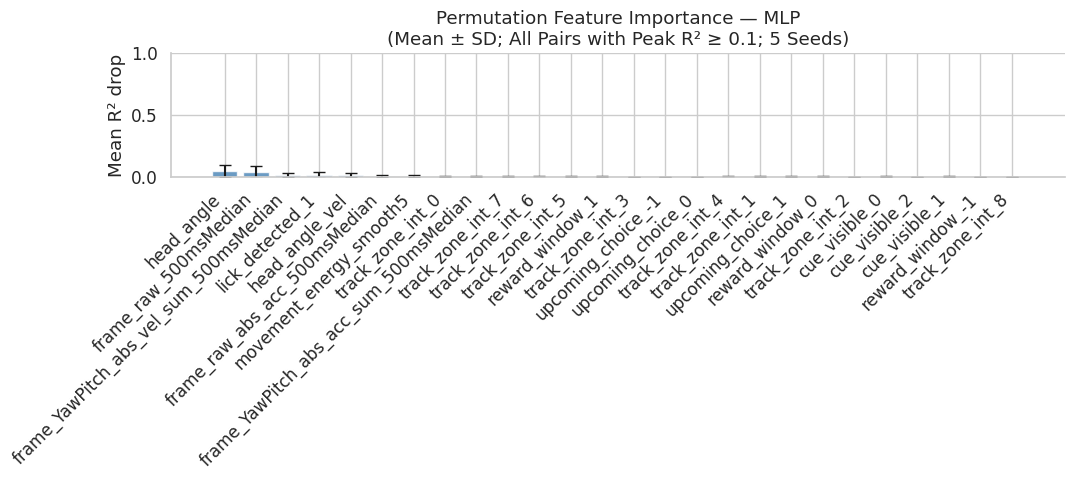

In [61]:
# ── Feature importance bar chart ───────────────────────────────────────────
imp_flat   = importance_masked.reshape(-1, n_feats)
feat_mean  = np.nanmean(imp_flat, axis=0)
feat_std   = np.nanstd(imp_flat,  axis=0)
feat_order = np.argsort(feat_mean)[::-1]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(n_feats)
ax.bar(x, feat_mean[feat_order], yerr=feat_std[feat_order],
       color='steelblue', capsize=4, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([all_feat_cols[i] for i in feat_order], rotation=45, ha='right')
ax.set_ylabel('Mean R² drop')
ax.set_title(f'Permutation Feature Importance — MLP\n'
             f'(Mean ± SD; All Pairs with Peak R² ≥ {R2_THRESHOLD}; {len(SEEDS)} Seeds)')
ax.set_ylim(0, 1.0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_619175/835848500.py:2: RuntimeWarning: Mean of empty slice
  neuron_importance = np.nanmean(importance_masked, axis=0)  # (n_neurons, n_feats)


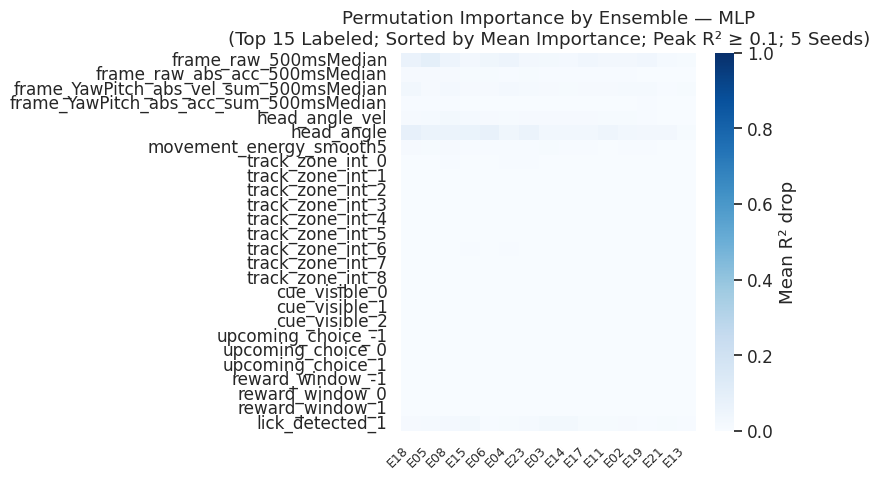

In [62]:
# ── Importance heatmap: feature × neuron (mean over sessions) ──────────────
neuron_importance = np.nanmean(importance_masked, axis=0)  # (n_neurons, n_feats)
valid_neurons     = ~np.all(np.isnan(neuron_importance), axis=1)

hm_data       = neuron_importance[valid_neurons, :].T
orig_n_idx    = np.where(valid_neurons)[0]
order_n       = np.argsort(np.nanmean(hm_data, axis=0))[::-1]   # best first
hm_data       = hm_data[:, order_n]
sorted_orig   = orig_n_idx[order_n]

N_LABEL   = 15
n_valid   = len(sorted_orig)
xtick_labels = [f"{prefix_name}{sorted_orig[i]+1:02d}" if i < N_LABEL else ''
                for i in range(n_valid)]

fig, ax = plt.subplots(figsize=(max(8, n_valid * 0.35), 5))
sns.heatmap(hm_data,
            xticklabels=xtick_labels,
            yticklabels=all_feat_cols,
            cmap='Blues', ax=ax, vmin=0, vmax=1.0, cbar_kws={'label': 'Mean R² drop'})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.title(f'Permutation Importance by {unit_label.capitalize()} — MLP\n'
          f'(Top {N_LABEL} Labeled; Sorted by Mean Importance; Peak R² ≥ {R2_THRESHOLD}; {len(SEEDS)} Seeds)')
plt.tight_layout()
plt.show()

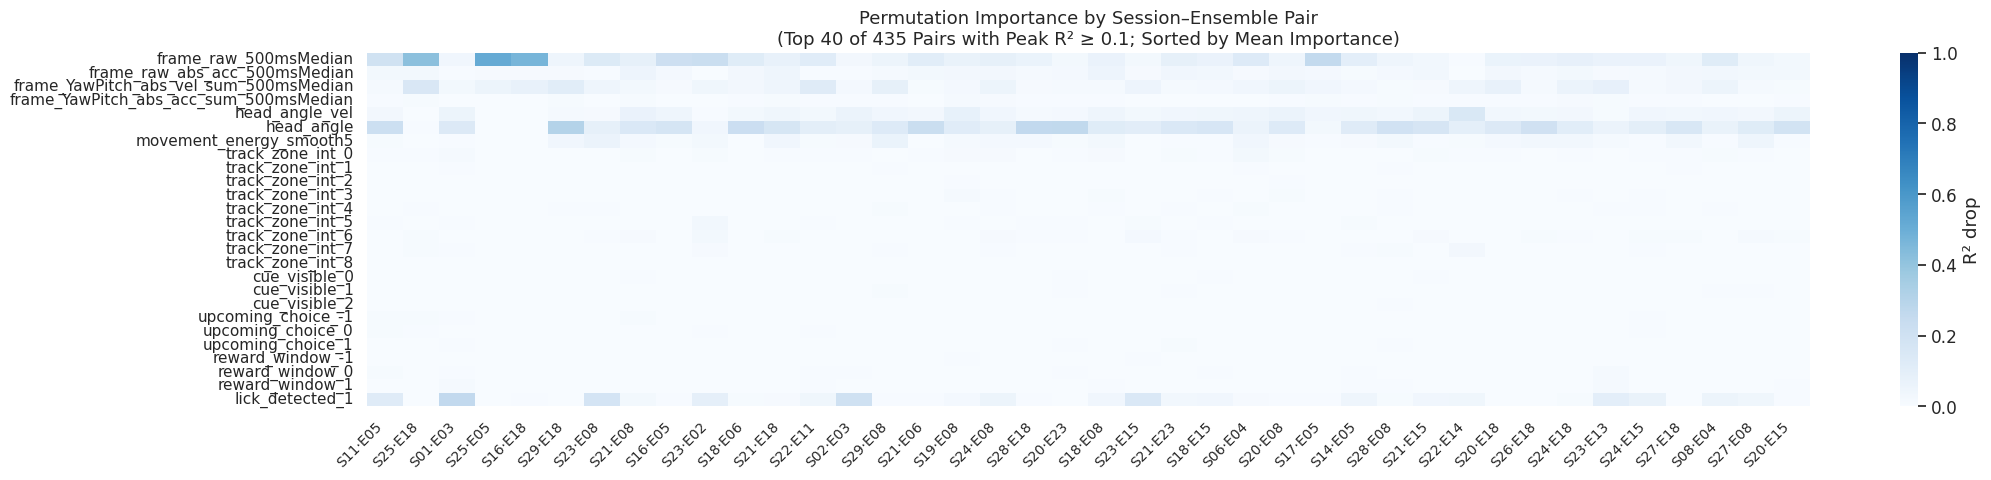

In [63]:
# ── Importance heatmap: feature × session-neuron pair ─────────────────────
pair_labels, imp_cols = [], []
for s in range(num_sessions):
    for n in range(num_neurons):
        row = importance_masked[s, n, :]
        if not np.all(np.isnan(row)):
            pair_labels.append(f"S{s+1:02d}·{prefix_name}{n+1:02d}")
            imp_cols.append(row)

if not imp_cols:
    print(f"No pairs with R² ≥ {R2_THRESHOLD}")
else:
    hm_data     = np.array(imp_cols).T
    order_p     = np.argsort(np.nanmean(hm_data, axis=0))[::-1]
    hm_data     = hm_data[:, order_p]
    pair_labels = [pair_labels[i] for i in order_p]

    # Show top-N pairs, all labeled, sized so columns are readable.
    N_SHOW  = min(40, len(pair_labels))
    hm_show = hm_data[:, :N_SHOW]
    xtick_labels = pair_labels[:N_SHOW]

    cell_w = 0.55
    fig_w  = max(10, N_SHOW * cell_w)

    fig, ax = plt.subplots(figsize=(fig_w, 5))
    sns.heatmap(hm_show,
                xticklabels=xtick_labels,
                yticklabels=all_feat_cols,
                cmap='Blues', ax=ax, vmin=0, vmax=1.0, cbar_kws={'label': 'R² drop'})
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
    plt.title(f'Permutation Importance by Session–{unit_label.capitalize()} Pair\n'
              f'(Top {N_SHOW} of {len(pair_labels)} Pairs with Peak R² ≥ {R2_THRESHOLD}; Sorted by Mean Importance)', fontsize=13)
    plt.tight_layout()
    plt.show()

In [64]:
if RUN_CONSISTENCY:
    def pairwise_embed_r2(embeddings_list):
        lr, scores = LinearRegression(), []
        for i, j in itertools.combinations(range(len(embeddings_list)), 2):
            ei, ej = embeddings_list[i], embeddings_list[j]
            scores.append(lr.fit(ei, ej).score(ei, ej))
            scores.append(lr.fit(ej, ei).score(ej, ei))
        return np.array(scores)

    consistency_matrix = np.full((num_sessions, num_neurons), np.nan)

    for test_idx, test_session in enumerate(session_ids):
        session_data  = session_dataset_singles[test_session]["data"]
        all_trial_ids = sorted(session_data.keys())
        full_data = torch.tensor(
            np.concatenate([session_data[tid] for tid in all_trial_ids], axis=0),
            dtype=torch.float32).to(device)

        for neuron_idx in range(num_neurons):
            if mask[test_idx, neuron_idx]:
                continue
            if mean_r2[test_idx, neuron_idx] < CONSISTENCY_THRESHOLD:
                continue

            embeddings_list = []
            for seed in SEEDS:
                mdir  = os.path.join(models_root, f"seed{seed}")
                mpath = os.path.join(mdir, f"session_{test_idx:02d}_neuron_{neuron_idx:02d}.pt")
                if not os.path.exists(mpath):
                    continue
                model = MLP(input_size, hidden_size, num_hidden_layers, output_size).to(device)
                model.load_state_dict(torch.load(mpath, map_location=device))
                model.eval()
                with torch.no_grad():
                    emb = model.embed(full_data).cpu().numpy()
                embeddings_list.append(emb)
                del model

            if len(embeddings_list) >= 2:
                scores = pairwise_embed_r2(embeddings_list)
                consistency_matrix[test_idx, neuron_idx] = scores.mean()

            torch.cuda.empty_cache()

        del full_data
        torch.cuda.empty_cache()
        print(f"Session {test_idx+1}/{num_sessions} consistency done.")

    np.save(os.path.join(output_dir, "consistency_matrix.npy"), consistency_matrix)
    print(f"Saved. Mean consistency R²: {np.nanmean(consistency_matrix[~mask]):.3f}")
else:
    print("Skipping consistency (RUN_CONSISTENCY=False) — load from disk in next cell.")

Skipping consistency (RUN_CONSISTENCY=False) — load from disk in next cell.


In [65]:
# ── Reload saved consistency (skip computation above if already run) ────────
consistency_matrix = np.load(os.path.join(output_dir, "consistency_matrix.npy"))
print(f"Mean consistency R² (good {unit_label_pl}): {np.nanmean(consistency_matrix[~mask]):.3f}")

Mean consistency R² (good ensembles): 0.840


/tmp/ipykernel_619175/1549263768.py:54: RuntimeWarning: Mean of empty slice
  cons_mean_all = np.nanmean(consistency_matrix, axis=0)
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


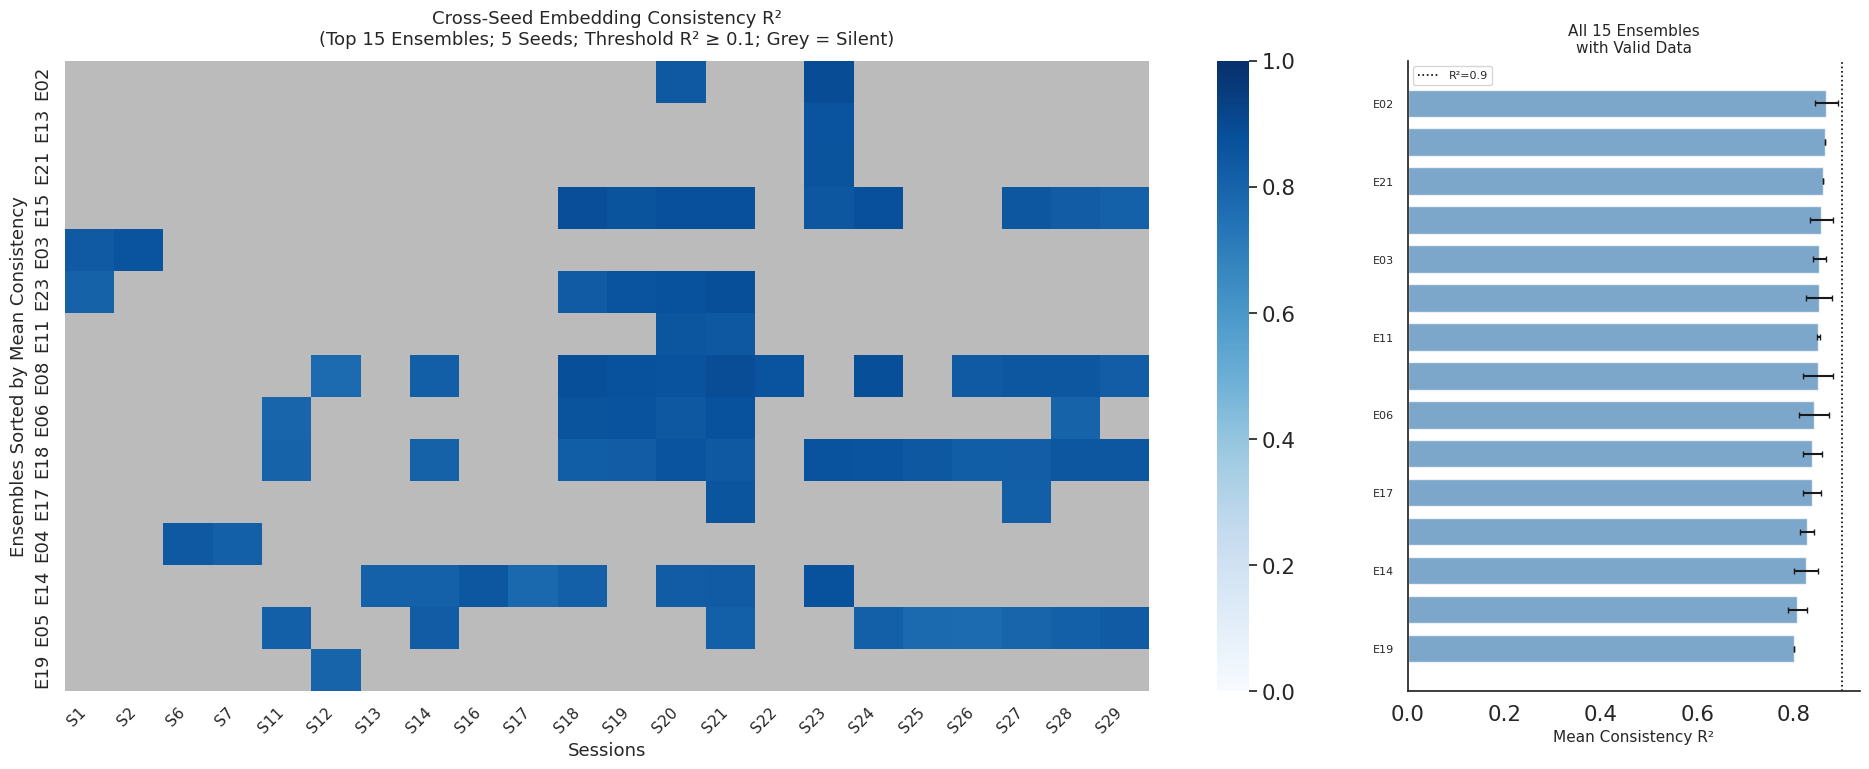

In [66]:
# ── Consistency heatmap ───────────────────────────────────────────────────
cons_valid_n = ~np.all(~np.isfinite(consistency_matrix) | mask, axis=0)
cons_valid_s = ~np.all(~np.isfinite(consistency_matrix) | mask, axis=1)
n_cvn, n_cvs = cons_valid_n.sum(), cons_valid_s.sum()

cons_filt  = consistency_matrix[np.ix_(cons_valid_s, cons_valid_n)]
mask_cfilt = mask[np.ix_(cons_valid_s, cons_valid_n)]

neuron_mean_cons  = np.nanmean(cons_filt, axis=0)
neuron_order_cons = np.argsort(neuron_mean_cons)[::-1]

valid_cn_idx  = np.where(cons_valid_n)[0]
valid_cs_idx  = np.where(cons_valid_s)[0]

N_SHOW        = min(30, n_cvn)
show_idx      = neuron_order_cons[:N_SHOW]
sorted_cn_show = valid_cn_idx[show_idx]

cons_show  = cons_filt[:, show_idx].T
mask_cshow = mask_cfilt[:, show_idx].T

ytick_labels = [f"{prefix_name}{sorted_cn_show[i]+1:02d}" for i in range(N_SHOW)]
xtick_labels = [f"S{j+1}" for j in valid_cs_idx]

cell_h = 0.45
cell_w = 0.50
fig_h  = max(8, N_SHOW * cell_h)
fig_w  = max(14, n_cvs * cell_w) + 5

NO_DATA_COLOR = '#bbbbbb'   # grey — unambiguously not a blue-scale value

cmap_cons = plt.cm.Blues.copy()
cmap_cons.set_bad(color=NO_DATA_COLOR)
cons_plot = cons_show.astype(float)
cons_plot[mask_cshow] = np.nan

sns.set_theme(style="white", font_scale=1.4)
fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), gridspec_kw={'width_ratios': [3, 1]})

sns.heatmap(cons_plot, cmap=cmap_cons, vmin=0, vmax=1,
            xticklabels=xtick_labels, yticklabels=ytick_labels, ax=axes[0])
for (i, j) in zip(*np.where(mask_cshow)):
    axes[0].add_patch(plt.Rectangle([j, i], 1, 1, fill=True, facecolor=NO_DATA_COLOR,
                                     hatch='////', edgecolor='#888888', lw=0.5, zorder=2))
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=13)
axes[0].set_xticklabels(axes[0].get_xticklabels(), fontsize=11, rotation=45, ha='right')
axes[0].set_title(f'Cross-Seed Embedding Consistency R²\n'
                  f'(Top {N_SHOW} {unit_label_pl.capitalize()}; {len(SEEDS)} Seeds; Threshold R² ≥ {CONSISTENCY_THRESHOLD}; Grey = Silent)',
                  fontsize=13, pad=12)
axes[0].set_xlabel('Sessions', fontsize=13)
axes[0].set_ylabel(f'{unit_label_pl.capitalize()} Sorted by Mean Consistency', fontsize=13)

# Right panel: only neurons with ≥1 valid consistency value.
cons_mean_all = np.nanmean(consistency_matrix, axis=0)
cons_std_all  = np.nanstd(consistency_matrix,  axis=0)
has_cons      = np.isfinite(cons_mean_all) & ~np.all(mask, axis=0)
bar_idx       = np.where(has_cons)[0]
bar_mean      = cons_mean_all[bar_idx]
bar_std       = cons_std_all[bar_idx]
bar_order     = np.argsort(bar_mean)
xn            = np.arange(len(bar_idx))

axes[1].barh(xn, bar_mean[bar_order], xerr=bar_std[bar_order],
             color='steelblue', alpha=0.7, capsize=2, height=0.7)
axes[1].set_yticks(xn[::2])
axes[1].set_yticklabels(
    [f"{prefix_name}{bar_idx[bar_order[i]]+1:02d}" for i in range(0, len(xn), 2)],
    fontsize=8)
axes[1].axvline(0.9, color='black', linestyle=':', linewidth=1.2, label='R²=0.9')
axes[1].set_xlabel('Mean Consistency R²', fontsize=11)
axes[1].set_title(f'All {len(bar_idx)} {unit_label_pl.capitalize()}\nwith Valid Data', fontsize=11)
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

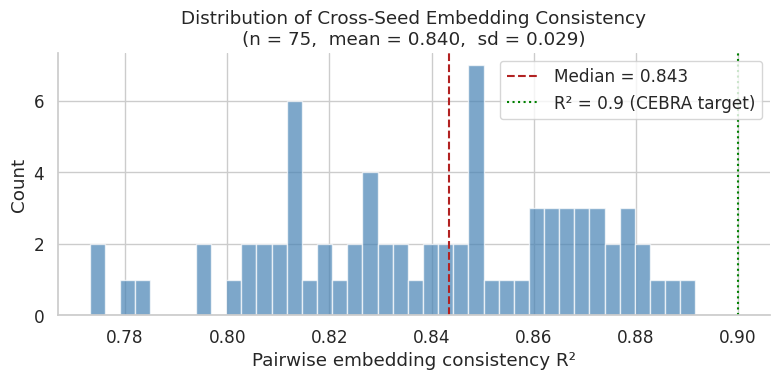

In [67]:
# ── Consistency distribution ───────────────────────────────────────────────
valid_cons = consistency_matrix[~mask & np.isfinite(consistency_matrix)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(valid_cons, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(np.median(valid_cons), color='firebrick', lw=1.5, linestyle='--',
           label=f'Median = {np.median(valid_cons):.3f}')
ax.axvline(0.9, color='green', lw=1.5, linestyle=':',
           label='R² = 0.9 (CEBRA target)')
ax.set_xlabel('Pairwise embedding consistency R²')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of Cross-Seed Embedding Consistency\n'
             f'(n = {len(valid_cons)},  mean = {np.nanmean(valid_cons):.3f},  sd = {np.nanstd(valid_cons):.3f})')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

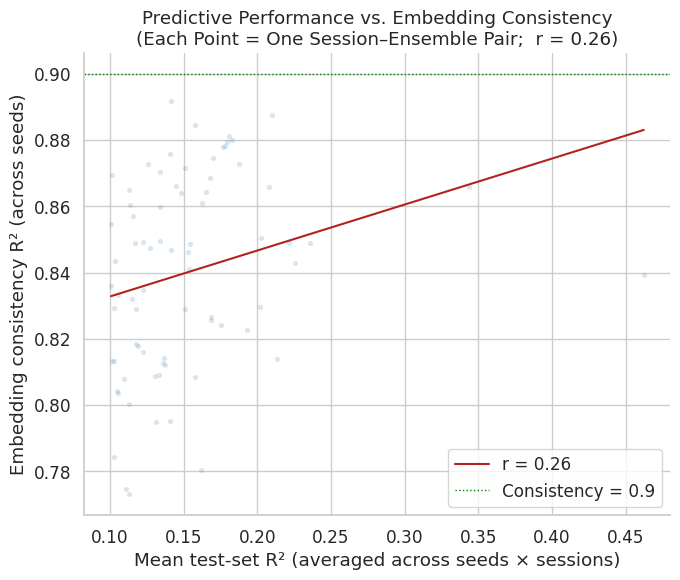

In [68]:
# ── Predictive R² vs embedding consistency scatter ────────────────────────
valid  = ~mask & np.isfinite(consistency_matrix)
cons_f = consistency_matrix[valid]
r2_f   = np.clip(mean_r2, 0, 1)[valid]
finite = np.isfinite(cons_f) & np.isfinite(r2_f)
cons_f, r2_f = cons_f[finite], r2_f[finite]

r_pearson = np.corrcoef(r2_f, cons_f)[0, 1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(r2_f, cons_f, alpha=0.15, s=8, color='steelblue')
m, b = np.polyfit(r2_f, cons_f, 1)
x_line = np.linspace(r2_f.min(), r2_f.max(), 200)
ax.plot(x_line, m * x_line + b, color='firebrick', lw=1.5, label=f'r = {r_pearson:.2f}')
ax.axhline(0.9, color='green', linestyle=':', lw=1, label='Consistency = 0.9')
ax.set_xlabel('Mean test-set R² (averaged across seeds × sessions)')
ax.set_ylabel('Embedding consistency R² (across seeds)')
ax.set_title(f'Predictive Performance vs. Embedding Consistency\n'
             f'(Each Point = One Session–{unit_label.capitalize()} Pair;  r = {r_pearson:.2f})')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

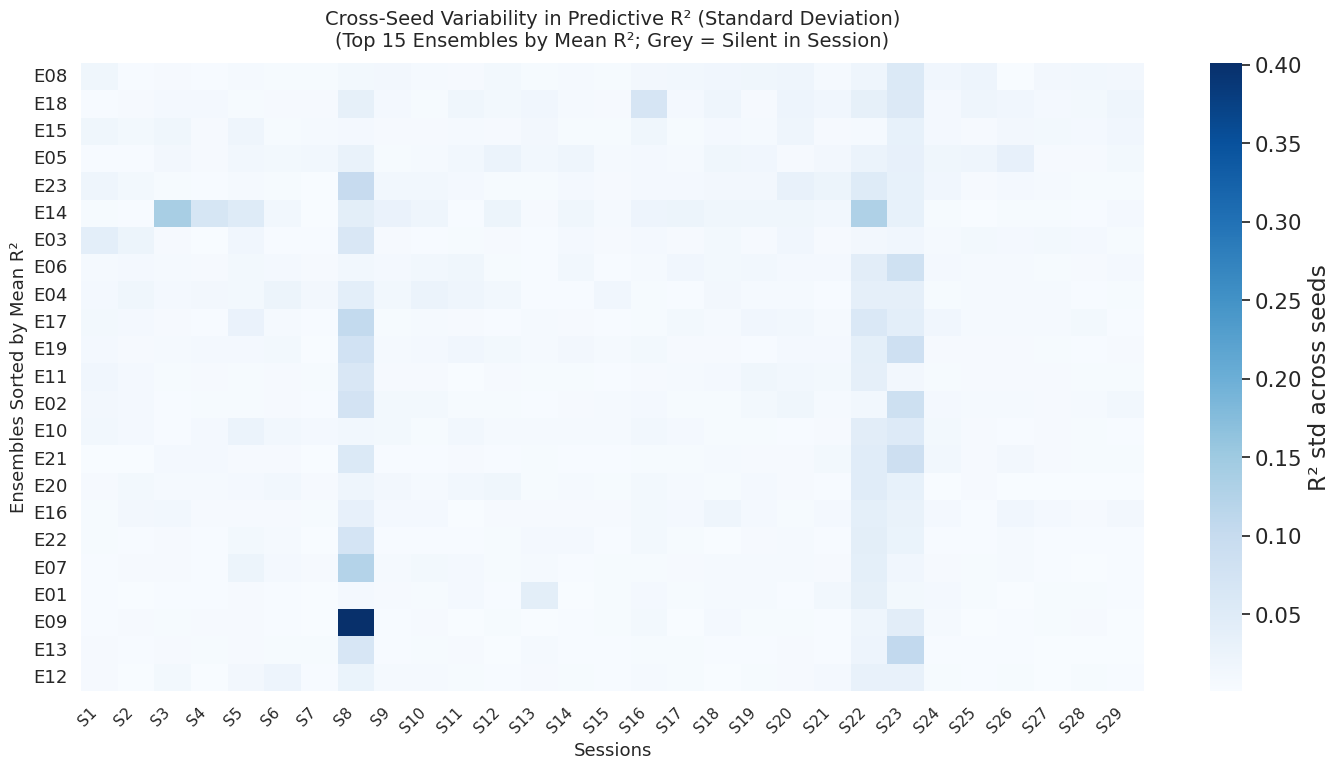

In [69]:
# ── Seed R² std heatmap (grouped with consistency — both measure cross-seed stability) ──
cell_h = 0.45
cell_w = 0.50
fig_h  = max(8, N_SHOW * cell_h)
fig_w  = max(14, n_vs * cell_w)

NO_DATA_COLOR = '#bbbbbb'

cmap_std = plt.cm.Blues.copy()
cmap_std.set_bad(color=NO_DATA_COLOR)
std_plot = std_show_data.astype(float)
std_plot[mask_show_data] = np.nan

sns.set_theme(style="white", font_scale=1.4)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(std_plot, cmap=cmap_std,
            xticklabels=r2_xtick_labels, yticklabels=r2_ytick_labels, ax=ax,
            cbar_kws={'label': 'R² std across seeds'})
for (i, j) in zip(*np.where(mask_show_data)):
    ax.add_patch(plt.Rectangle([j, i], 1, 1, fill=True, facecolor=NO_DATA_COLOR,
                                hatch='////', edgecolor='#888888', lw=0.5, zorder=2))
ax.set_yticklabels(ax.get_yticklabels(), fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=45, ha='right')
ax.set_title(f'Cross-Seed Variability in Predictive R² (Standard Deviation)\n'
             f'(Top {N_SHOW} {unit_label_pl.capitalize()} by Mean R²; Grey = Silent in Session)', fontsize=14, pad=12)
ax.set_xlabel('Sessions', fontsize=13)
ax.set_ylabel(f'{unit_label_pl.capitalize()} Sorted by Mean R²', fontsize=13)
plt.tight_layout()
plt.show()
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

Top 6 ensembles by max R² across sessions:
  E03 (max R² = 0.4623)
  E18 (max R² = 0.2359)
  E04 (max R² = 0.2132)
  E08 (max R² = 0.2099)
  E23 (max R² = 0.1793)
  E15 (max R² = 0.1781)
Top ensemble-feature pairs by mean permutation importance:
  E05 × frame_raw_500msMedian  (mean=0.0958)
  E18 × head_angle  (mean=0.0838)
  E06 × head_angle  (mean=0.0780)
  E18 × frame_raw_500msMedian  (mean=0.0699)
  E15 × head_angle  (mean=0.0653)


/tmp/ipykernel_619175/2351146086.py:15: RuntimeWarning: Mean of empty slice
  pair_mean  = np.nanmean(importance_masked, axis=0)  # (num_neurons, n_feats)


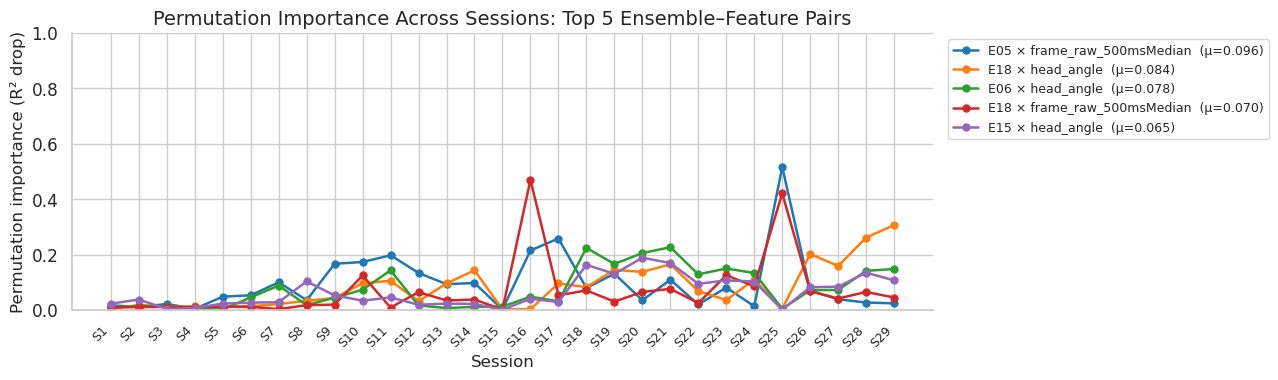

In [70]:
# ── Top-N neurons setup (used by next cell too) ───────────────────────────
TOP_K = 6

_nm = np.nanmax(np.where(mask, np.nan, mean_r2), axis=0)   # (num_neurons,)
top_neurons = np.argsort(_nm)[::-1][:TOP_K]
session_x   = np.arange(1, num_sessions + 1)

print(f"Top {TOP_K} {unit_label_pl} by max R² across sessions:")
for idx in top_neurons:
    print(f"  {prefix_name}{idx+1:02d} (max R² = {_nm[idx]:.4f})")

# ── Top neuron-feature pairs: permutation importance over sessions ─────────
TOP_K_PAIRS = 5

pair_mean  = np.nanmean(importance_masked, axis=0)  # (num_neurons, n_feats)
flat_order = np.argsort(pair_mean.ravel())[::-1]
top_pairs = []
while len(top_pairs) < TOP_K_PAIRS and flat_order.size > 0:
    idx = flat_order[0]
    n_idx, f_idx = int(idx // n_feats), int(idx % n_feats)
    if not np.isnan(pair_mean[n_idx, f_idx]):
        top_pairs.append((n_idx, f_idx))
    flat_order = flat_order[1:]

print(f"Top {unit_label}-feature pairs by mean permutation importance:")
for n_idx, f_idx in top_pairs:
    print(f"  {prefix_name}{n_idx+1:02d} × {all_feat_cols[f_idx]}  "
          f"(mean={pair_mean[n_idx, f_idx]:.4f})")

colors_pairs = sns.color_palette("tab10", TOP_K_PAIRS)

fig, ax = plt.subplots(figsize=(13, 4))
for k, (n_idx, f_idx) in enumerate(top_pairs):
    series = importance_masked[:, n_idx, f_idx]  # (num_sessions,)
    ax.plot(session_x, series, '-o', color=colors_pairs[k], markersize=5, lw=1.8,
            label=f"{prefix_name}{n_idx+1:02d} × {all_feat_cols[f_idx]}  "
                  f"(μ={pair_mean[n_idx, f_idx]:.3f})")

ax.axhline(0, color='grey', linestyle='--', lw=1)
ax.set_xticks(session_x)
ax.set_xticklabels([f"S{s}" for s in session_x], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Session', fontsize=12)
ax.set_ylabel('Permutation importance (R² drop)', fontsize=12)
ax.set_title(f'Permutation Importance Across Sessions: Top {TOP_K_PAIRS} {unit_label.capitalize()}–Feature Pairs',
             fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 1.0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

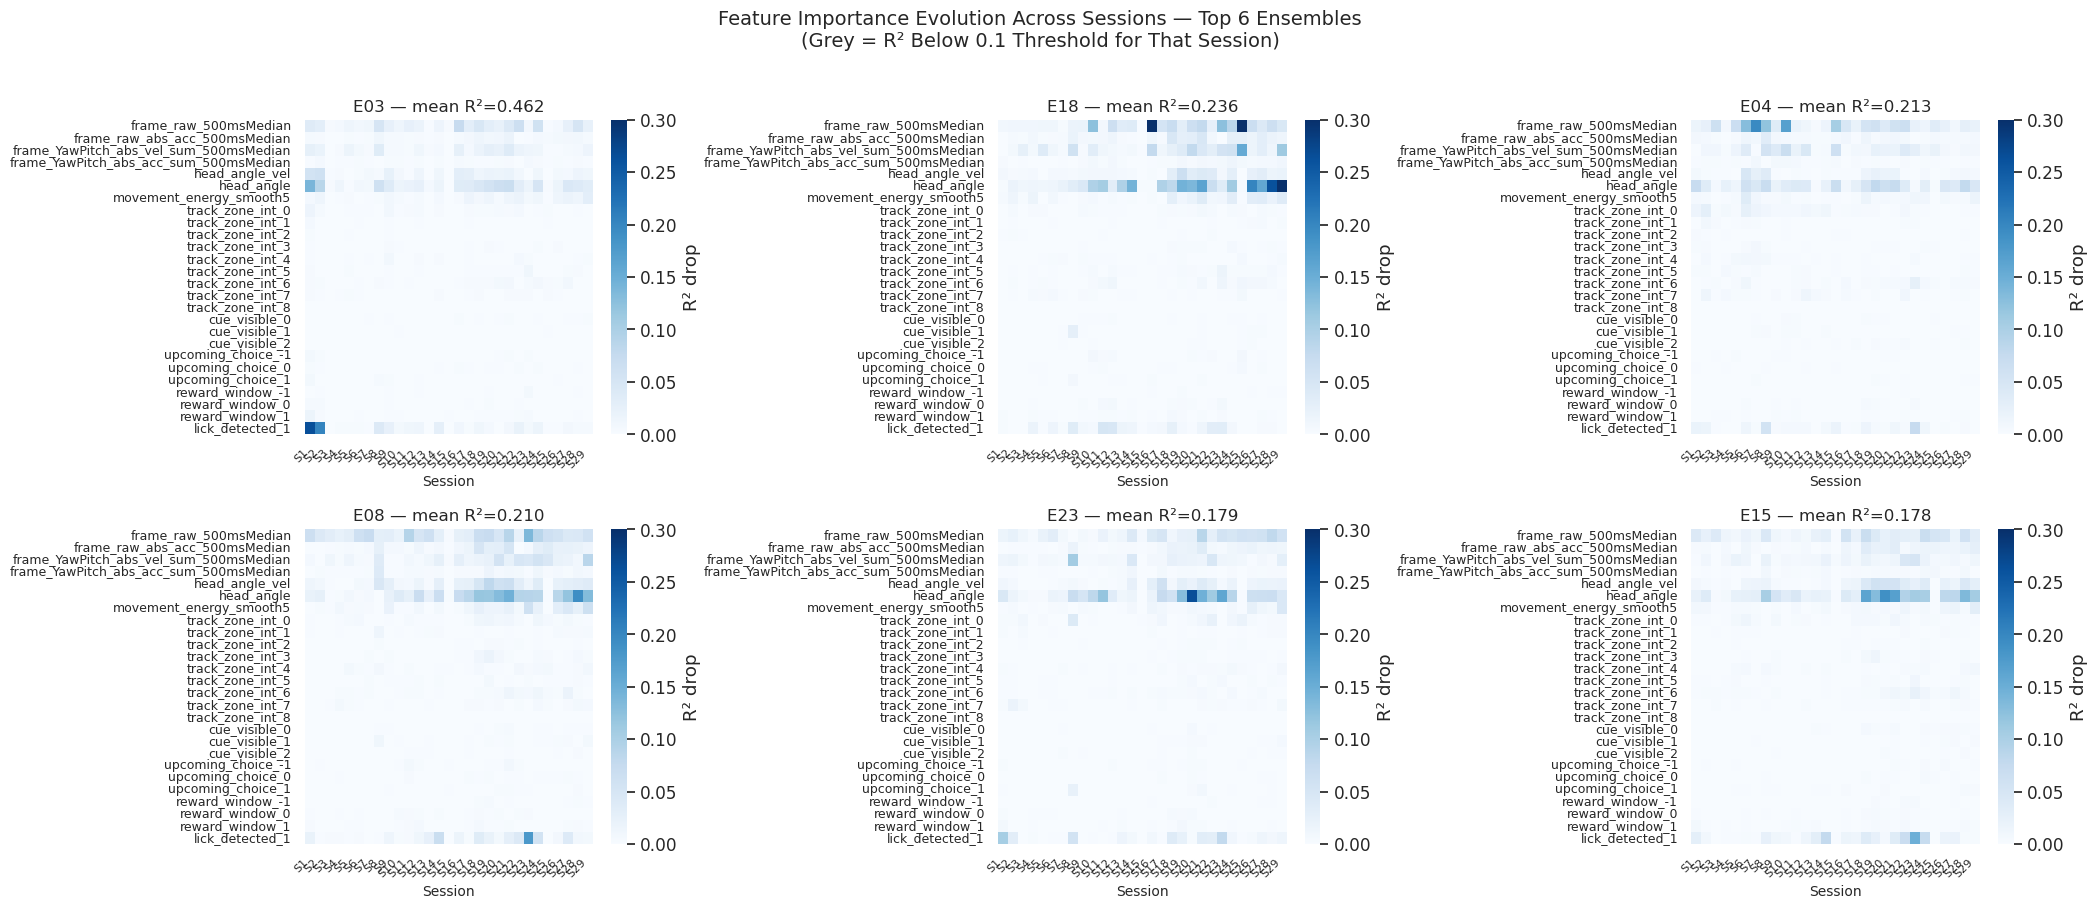

In [79]:
# ── Feature importance across sessions — one heatmap per top neuron ────────
NO_DATA_COLOR = '#bbbbbb'
ncols = min(3, TOP_K)
nrows = (TOP_K + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 7, nrows * 4.5),
                          squeeze=False)
axes_flat = axes.flatten()

for k, n_idx in enumerate(top_neurons):
    ax  = axes_flat[k]
    imp = importance_masked[:, n_idx, :].T   # (n_feats, n_sessions)

    cmap_i = plt.cm.Blues.copy()
    cmap_i.set_bad(NO_DATA_COLOR)

    sns.heatmap(imp, ax=ax, cmap=cmap_i, vmin=0, vmax=0.3,
                xticklabels=[f"S{s+1}" for s in range(num_sessions)],
                yticklabels=all_feat_cols,
                cbar_kws={'label': 'R² drop'})
    # Grey hatching over all-NaN sessions (neuron below threshold that session)
    for j in range(num_sessions):
        if np.all(np.isnan(imp[:, j])):
            ax.add_patch(plt.Rectangle([j, 0], 1, len(all_feat_cols),
                                        fill=True, facecolor=NO_DATA_COLOR,
                                        hatch='////', edgecolor='#888888', lw=0.5, zorder=2))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
    ax.set_title(f"{prefix_name}{n_idx+1:02d} — mean R²={_nm[n_idx]:.3f}", fontsize=12)
    ax.set_xlabel('Session', fontsize=10)

for k in range(TOP_K, len(axes_flat)):
    axes_flat[k].set_visible(False)

plt.suptitle(f'Feature Importance Evolution Across Sessions — Top {TOP_K} {unit_label_pl.capitalize()}\n'
             f'(Grey = R² Below {R2_THRESHOLD} Threshold for That Session)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [72]:
from scipy.ndimage import uniform_filter1d

# ── Example / trend-noise analysis parameters ──────────────────────────────
N_EXAMPLE_PAIRS  = 5    # (session, neuron) pairs to analyse (top by mean R²)
TREND_WINDOW     = 10   # smoothing window (timesteps) for trend/noise split
SMOOTH_WINDOWS   = [1, 2, 5, 10, 20, 40]   # windows for the smoothed-R² curve


In [73]:
# ── Run inference for top N pairs — selected by dominant slow component ───────────
# Score every valid (session, neuron) pair by the absolute variance of its slow
# trend: trend_var = var(smooth(actual, TREND_WINDOW)).
# High trend_var → trend is actually moving (not a flat baseline), which makes
# the predicted-vs-actual traces visually interesting. Candidate pool restricted
# to pairs with mean R² >= R2_THRESHOLD so the model has something real to track.

from scipy.ndimage import uniform_filter1d

# ── Score candidates ────────────────────────────────────────────────────────────────
slow_frac_scores = {}  # (s_idx, n_idx) -> absolute trend variance
valid_r2 = np.where(mask, np.nan, mean_r2)

for s_idx in range(num_sessions):
    session_id     = session_ids[s_idx]
    session_labels = session_dataset_singles[session_id]['labels']
    all_trials     = sorted(session_labels.keys())
    for n_idx in range(num_neurons):
        if np.isnan(valid_r2[s_idx, n_idx]):
            continue
        actual = np.concatenate([session_labels[tid][:, n_idx] for tid in all_trials])
        v_total = np.var(actual)
        if v_total < 1e-8:
            continue
        trend = uniform_filter1d(actual.astype(np.float32), size=TREND_WINDOW, mode='nearest')
        slow_frac_scores[(s_idx, n_idx)] = np.var(trend)

top_pairs = sorted(slow_frac_scores, key=slow_frac_scores.get, reverse=True)[:N_EXAMPLE_PAIRS]
print(f'Selected {len(top_pairs)} pairs by slow-component dominance:')
for (s, n) in top_pairs:
    print(f'  S{s+1}·{prefix_name}{n+1:02d}  trend_var={slow_frac_scores[(s,n)]:.4f}  '
          f'R²={valid_r2[s, n]:.3f}')

# ── Run inference for selected pairs ───────────────────────────────────────────────
# example_cache[pair] = {
#   'actual_cat':   concatenated actual across all trials  (T_total,)
#   'pred_cat':     mean prediction across seeds            (T_total,)
#   'best_trial':   trial id with lowest inter-seed variance
#   'actual_trial': actual signal for best_trial            (T,)
#   'pred_trial':   mean prediction for best_trial          (T,)
#   'r2':           mean R² from eval
# }
example_cache = {}

for s_idx, n_idx in top_pairs:
    session_id     = session_ids[s_idx]
    session_data   = session_dataset_singles[session_id]['data']
    session_labels = session_dataset_singles[session_id]['labels']
    all_trials     = sorted(session_data.keys())

    seed_preds = {}  # seed -> {tid -> (T,)}
    for seed in SEEDS:
        mpath = os.path.join(models_root, f'seed{seed}',
                              f'session_{s_idx:02d}_neuron_{n_idx:02d}.pt')
        if not os.path.exists(mpath):
            continue
        model = MLP(input_size, hidden_size, num_hidden_layers, output_size).to(device)
        model.load_state_dict(torch.load(mpath, map_location=device))
        model.eval()
        pbt = {}
        for tid in all_trials:
            x = torch.tensor(session_data[tid].astype(np.float32)).to(device)
            with torch.no_grad():
                _, p = model(x)
            pbt[tid] = p.squeeze().cpu().numpy()
        seed_preds[seed] = pbt
        del model
        torch.cuda.empty_cache()

    if len(seed_preds) < 2:
        print(f'Skipping S{s_idx+1}\u00b7{prefix_name}{n_idx+1:02d}: fewer than 2 models found')
        continue

    pred_mean_by_trial = {
        tid: np.stack([seed_preds[s][tid] for s in seed_preds]).mean(axis=0)
        for tid in all_trials
    }

    # Best trial: lowest inter-seed variance (most consistent prediction).
    best_trial = min(
        all_trials,
        key=lambda tid: np.mean(np.var(
            np.stack([seed_preds[s][tid] for s in seed_preds]), axis=0
        ))
    )

    actual_cat = np.concatenate([session_labels[tid][:, n_idx] for tid in all_trials])
    pred_cat   = np.concatenate([pred_mean_by_trial[tid]       for tid in all_trials])

    example_cache[(s_idx, n_idx)] = {
        'actual_cat':   actual_cat,
        'pred_cat':     pred_cat,
        'best_trial':   best_trial,
        'actual_trial': session_labels[best_trial][:, n_idx],
        'pred_trial':   pred_mean_by_trial[best_trial],
        'r2':           valid_r2[s_idx, n_idx],
    }
    print(f'Cached S{s_idx+1}\u00b7{prefix_name}{n_idx+1:02d}  '
          f'(R\u00b2={valid_r2[s_idx, n_idx]:.3f},  '
          f'trend_var={slow_frac_scores[(s_idx, n_idx)]:.4f},  '
          f'{len(actual_cat)} timesteps)')


Selected 5 pairs by slow-component dominance:
  S1·E03  trend_var=0.5767  R²=0.462
  S23·E21  trend_var=0.4615  R²=0.114
  S2·E03  trend_var=0.4467  R²=0.344
  S23·E02  trend_var=0.3948  R²=0.142
  S28·E18  trend_var=0.3789  R²=0.236
Cached S1·E03  (R²=0.462,  trend_var=0.5767,  22910 timesteps)
Cached S23·E21  (R²=0.114,  trend_var=0.4615,  5225 timesteps)
Cached S2·E03  (R²=0.344,  trend_var=0.4467,  41847 timesteps)
Cached S23·E02  (R²=0.142,  trend_var=0.3948,  5225 timesteps)
Cached S28·E18  (R²=0.236,  trend_var=0.3789,  57776 timesteps)


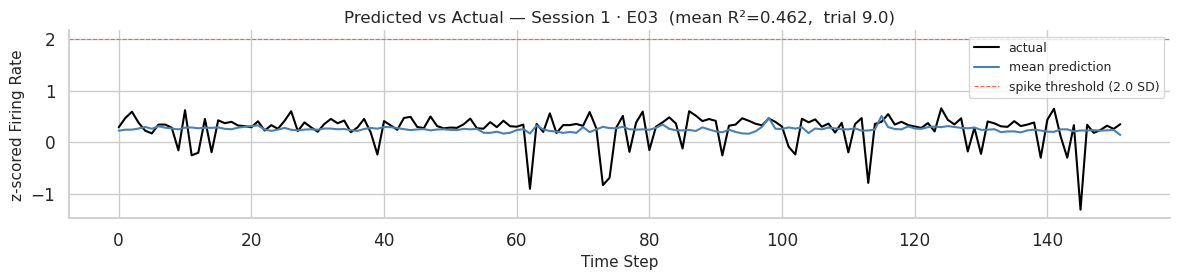

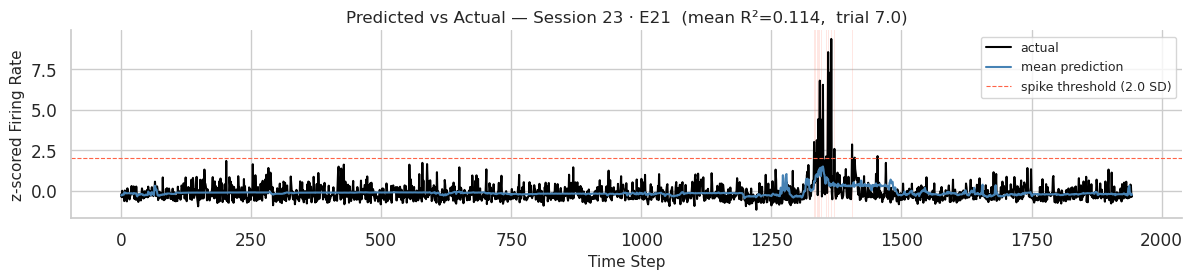

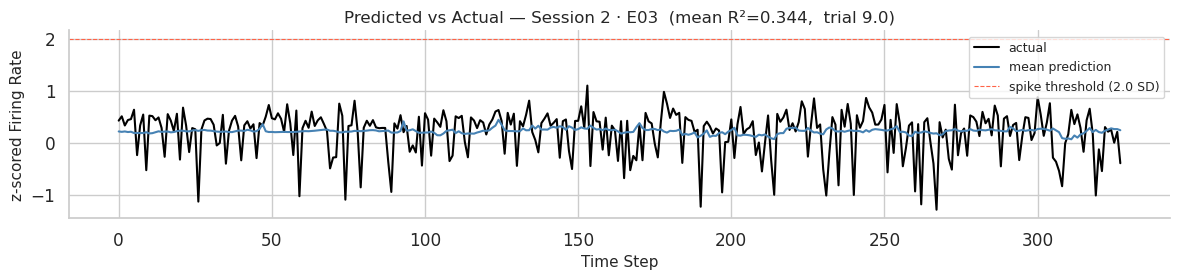

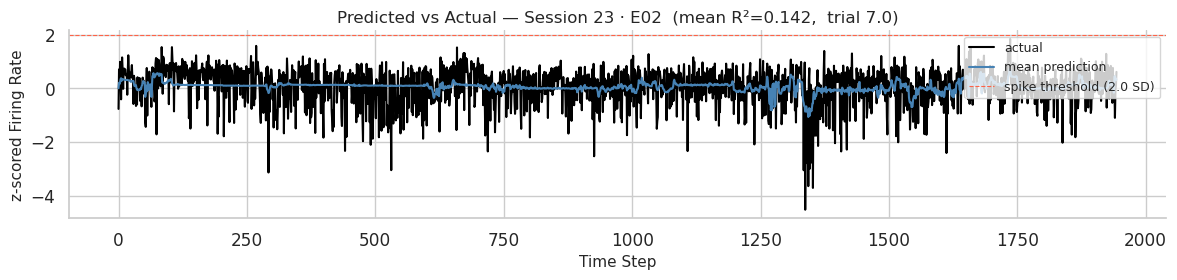

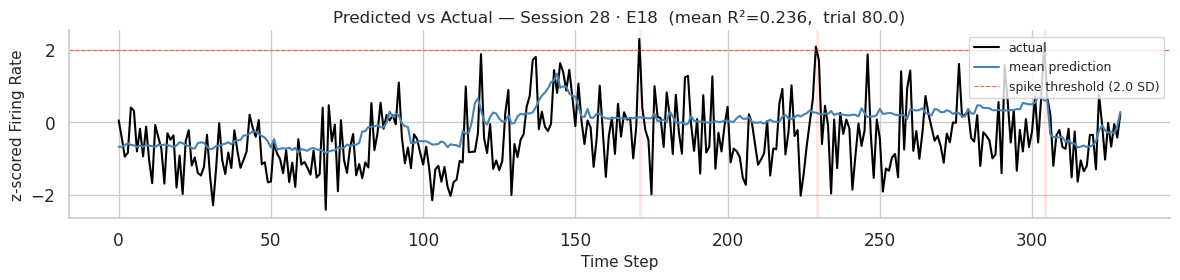

In [74]:
# ── Predicted vs actual — best trial per pair ─────────────────────────────
SPIKE_THRESH = 2.0

for (s_idx, n_idx), cache in example_cache.items():
    actual    = cache['actual_trial']
    pred_mean = cache['pred_trial']
    T = len(actual)
    t = np.arange(T)

    fig, ax = plt.subplots(figsize=(12, 3))

    in_spike = False
    for i in range(T):
        if actual[i] >= SPIKE_THRESH and not in_spike:
            spike_start, in_spike = i, True
        elif actual[i] < SPIKE_THRESH and in_spike:
            ax.axvspan(spike_start, i, color='tomato', alpha=0.15, lw=0)
            in_spike = False
    if in_spike:
        ax.axvspan(spike_start, T, color='tomato', alpha=0.15, lw=0)

    ax.plot(t, actual,    color='black',     lw=1.5, label='actual')
    ax.plot(t, pred_mean, color='steelblue', lw=1.5, label='mean prediction')
    ax.axhline(SPIKE_THRESH, color='tomato', lw=0.8, linestyle='--',
               label=f'spike threshold ({SPIKE_THRESH} SD)')
    ax.set_xlabel('Time Step', fontsize=11)
    ax.set_ylabel('z-scored Firing Rate', fontsize=11)
    ax.set_title(
        f'Predicted vs Actual — Session {s_idx+1} · {prefix_name}{n_idx+1:02d}  '
        f'(mean R²={cache["r2"]:.3f},  trial {cache["best_trial"]})',
        fontsize=12
    )
    ax.legend(loc='upper right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


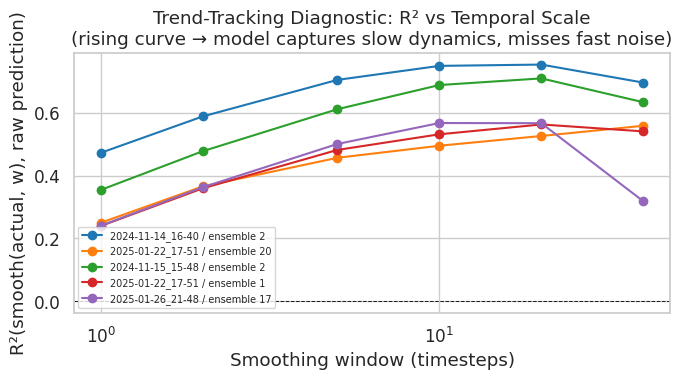

In [75]:
# ── Approach 1: R² vs smoothing window ────────────────────────────────────────────
# Smooth only the actual at window w and compare to the *raw* prediction.
# Rising R² with window directly shows the model captures slow dynamics
# better than fast fluctuations (it is a low-pass filter).

colors_p = sns.color_palette('tab10', len(example_cache))
fig, ax = plt.subplots(figsize=(7, 4))

for ki, ((s_idx, n_idx), cache) in enumerate(example_cache.items()):
    actual = cache['actual_cat']
    pred   = cache['pred_cat']
    curve  = [
        r2_score(uniform_filter1d(actual.astype(float), size=w, mode='nearest'), pred)
        for w in SMOOTH_WINDOWS
    ]
    ses_lbl = session_ids[s_idx]
    ax.plot(SMOOTH_WINDOWS, curve, 'o-', color=colors_p[ki],
            label=f"{ses_lbl} / {unit_label} {n_idx}")

ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_xscale('log')
ax.set_xlabel('Smoothing window (timesteps)')
ax.set_ylabel(r'R²(smooth(actual, w), raw prediction)')
ax.set_title(
    f'Trend-Tracking Diagnostic: R\u00b2 vs Temporal Scale\n'
    f'(rising curve \u2192 model captures slow dynamics, misses fast noise)'
)
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


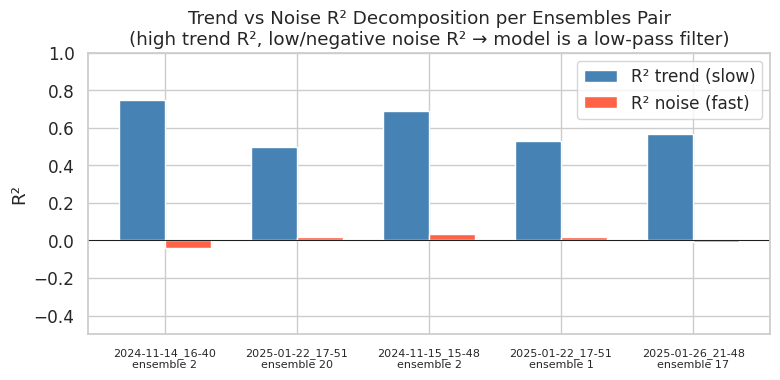

In [76]:
# ── Approach 2: trend vs noise R² decomposition ────────────────────────────────────
# trend_actual = smooth(actual, TREND_WINDOW)
# noise_actual  = actual - trend_actual
# noise_pred    = pred   - smooth(pred,   TREND_WINDOW)
#
# R²_trend = r2_score(trend_actual, pred)        # raw pred vs slow component
# R²_noise = r2_score(noise_actual, noise_pred)  # HF pred vs HF actual

pair_labels, r2_trend_vals, r2_noise_vals = [], [], []

for (s_idx, n_idx), cache in example_cache.items():
    actual = cache['actual_cat']
    pred   = cache['pred_cat']

    trend_actual = uniform_filter1d(actual.astype(float), size=TREND_WINDOW, mode='nearest')
    noise_actual = actual - trend_actual
    noise_pred   = pred   - uniform_filter1d(pred, size=TREND_WINDOW, mode='nearest')

    r2_t = r2_score(trend_actual, pred)
    r2_n = r2_score(noise_actual, noise_pred) if np.var(noise_actual) > 1e-8 else np.nan

    pair_labels.append(f"{session_ids[s_idx]}\n{unit_label} {n_idx}")
    r2_trend_vals.append(r2_t)
    r2_noise_vals.append(r2_n)

x = np.arange(len(pair_labels))
bw = 0.35
fig, ax = plt.subplots(figsize=(max(6, len(pair_labels) * 1.6), 4))
ax.bar(x - bw/2, r2_trend_vals, bw, label='R² trend (slow)', color='steelblue')
ax.bar(x + bw/2, r2_noise_vals, bw, label='R² noise (fast)', color='tomato')

ax.axhline(0, color='k', lw=0.7)
ax.set_xticks(x)
ax.set_xticklabels(pair_labels, fontsize=8)
ax.set_ylabel('R²')
ax.set_ylim(-0.5, 1.0)
ax.set_title(
    f'Trend vs Noise R² Decomposition per {unit_label_pl.capitalize()} Pair\n'
    f'(high trend R², low/negative noise R² \u2192 model is a low-pass filter)'
)
ax.legend()
plt.tight_layout()
plt.show()


In [77]:
# ── Condition-wise activation: actual vs predicted per (session, neuron) ───
NEURON_ENSEMBLE_FEAT = {
    6:  {'ensemble': 'Assembly007', 'feature': 'cue_visible'},
    22: {'ensemble': 'Assembly023', 'feature': 'upcoming_choice'},
}
TARGET_NEURONS = list(NEURON_ENSEMBLE_FEAT.keys())

def onehot_cols_for(feat):
    return sorted([c for c in all_feat_cols if c.startswith(feat + '_')])

def cond_vals_for(feat):
    return [int(c.split('_')[-1]) for c in onehot_cols_for(feat)]

# per-neuron arrays: (n_seeds, n_sessions, n_conds, 2)  last dim: 0=actual, 1=pred
cond_means_raw = {n: np.full((len(SEEDS), num_sessions, len(cond_vals_for(v['feature'])), 2), np.nan)
                  for n, v in NEURON_ENSEMBLE_FEAT.items()}

for seed_idx, seed in enumerate(SEEDS):
    split_path    = os.path.join(splits_dir, f"split_seed{seed}.npy")
    models_dir_s  = os.path.join(models_root, f"seed{seed}")
    test_idx_by_s = np.load(split_path, allow_pickle=True).item()

    for s_idx, sess in enumerate(session_ids):
        sdata        = session_dataset_singles[sess]
        test_trials  = test_idx_by_s[sess]
        test_data_np = np.concatenate([sdata["data"][t]   for t in test_trials], axis=0).astype(np.float32)
        test_lbls_np = np.concatenate([sdata["labels"][t] for t in test_trials], axis=0)

        for neuron_idx in TARGET_NEURONS:
            if mask[s_idx, neuron_idx]:
                continue
            mpath = os.path.join(models_dir_s, f"session_{s_idx:02d}_neuron_{neuron_idx:02d}.pt")
            if not os.path.exists(mpath):
                continue

            model = MLP(input_size, hidden_size, num_hidden_layers, output_size).to(device)
            model.load_state_dict(torch.load(mpath, map_location=device))
            model.eval()
            with torch.no_grad():
                _, preds = model(torch.tensor(test_data_np, dtype=torch.float32).to(device))
            preds_np  = preds.squeeze().cpu().numpy()
            actual_np = test_lbls_np[:, neuron_idx]
            del model; torch.cuda.empty_cache()

            feat      = NEURON_ENSEMBLE_FEAT[neuron_idx]['feature']
            uc_cols   = onehot_cols_for(feat)
            cvals     = cond_vals_for(feat)
            feat_idxs = [all_feat_cols.index(c) for c in uc_cols]
            onehot    = test_data_np[:, feat_idxs]
            condition = np.full(len(test_data_np), np.nan)
            for ci, val in enumerate(cvals):
                condition[onehot[:, ci] > 0.5] = val

            for ci, cval in enumerate(cvals):
                m = condition == cval
                if m.sum() < 5:
                    continue
                cond_means_raw[neuron_idx][seed_idx, s_idx, ci, 0] = actual_np[m].mean()
                cond_means_raw[neuron_idx][seed_idx, s_idx, ci, 1] = preds_np[m].mean()

        del test_data_np, test_lbls_np
    print(f"Seed {seed} done.")

mean_cond = {n: np.nanmean(v, axis=0) for n, v in cond_means_raw.items()}  # (n_sessions, n_conds, 2)
print("Condition means computed.")


Seed 42 done.
Seed 43 done.
Seed 44 done.
Seed 45 done.
Seed 46 done.
Condition means computed.


/tmp/ipykernel_619175/2805530525.py:64: RuntimeWarning: Mean of empty slice
  mean_cond = {n: np.nanmean(v, axis=0) for n, v in cond_means_raw.items()}  # (n_sessions, n_conds, 2)


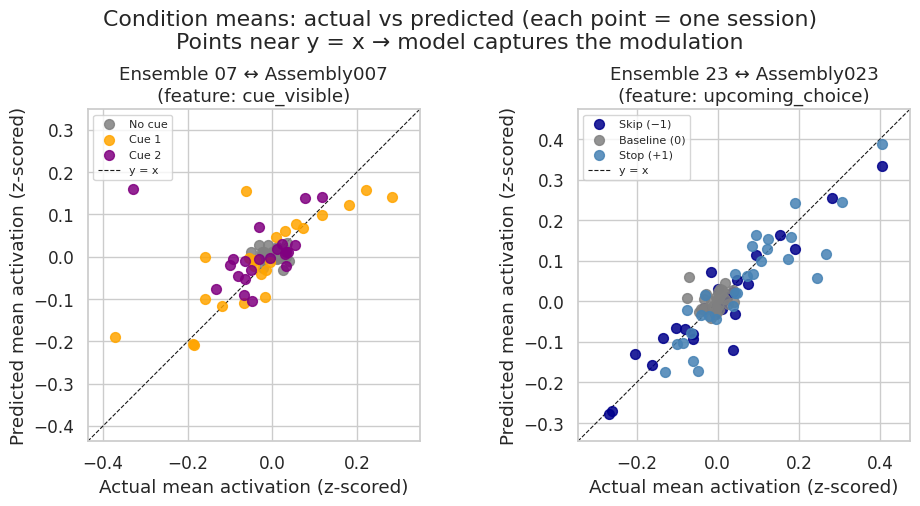

In [78]:
# ── Actual vs predicted condition means — scatter per target neuron ────────
COND_COLORS_BY_FEAT = {
    'upcoming_choice': {-1: 'darkblue', 0: 'gray', 1: 'steelblue'},
    'cue_visible':     {0: 'gray', 1: 'orange', 2: 'purple'},
}
COND_LABELS_BY_FEAT = {
    'upcoming_choice': {-1: 'Skip (−1)', 0: 'Baseline (0)', 1: 'Stop (+1)'},
    'cue_visible':     {0: 'No cue', 1: 'Cue 1', 2: 'Cue 2'},
}

plt.close('all')
fig, axes = plt.subplots(1, len(TARGET_NEURONS), figsize=(5 * len(TARGET_NEURONS), 5), squeeze=False)

for ni, neuron_idx in enumerate(TARGET_NEURONS):
    ax     = axes[0, ni]
    feat   = NEURON_ENSEMBLE_FEAT[neuron_idx]['feature']
    ens_id = NEURON_ENSEMBLE_FEAT[neuron_idx]['ensemble']
    cvals  = cond_vals_for(feat)
    colors = COND_COLORS_BY_FEAT[feat]
    labels = COND_LABELS_BY_FEAT[feat]
    mc     = mean_cond[neuron_idx]  # (n_sessions, n_conds, 2)

    all_vals = []
    for ci, cval in enumerate(cvals):
        xs, ys = mc[:, ci, 0], mc[:, ci, 1]
        valid  = np.isfinite(xs) & np.isfinite(ys)
        if valid.any():
            ax.scatter(xs[valid], ys[valid], color=colors[cval], label=labels[cval], s=50, alpha=0.85, zorder=3)
            all_vals.extend(xs[valid].tolist() + ys[valid].tolist())

    if all_vals:
        lo, hi = min(all_vals), max(all_vals)
        pad = (hi - lo) * 0.1
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=0.8, label='y = x', zorder=2)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)

    ax.set_xlabel('Actual mean activation (z-scored)')
    ax.set_ylabel('Predicted mean activation (z-scored)')
    ax.set_title(f'{unit_label_pl.capitalize()[:-1]} {neuron_idx + 1:02d} ↔ {ens_id}\n(feature: {feat})')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

plt.suptitle('Condition means: actual vs predicted (each point = one session)\nPoints near y = x → model captures the modulation')
plt.tight_layout()
plt.show()


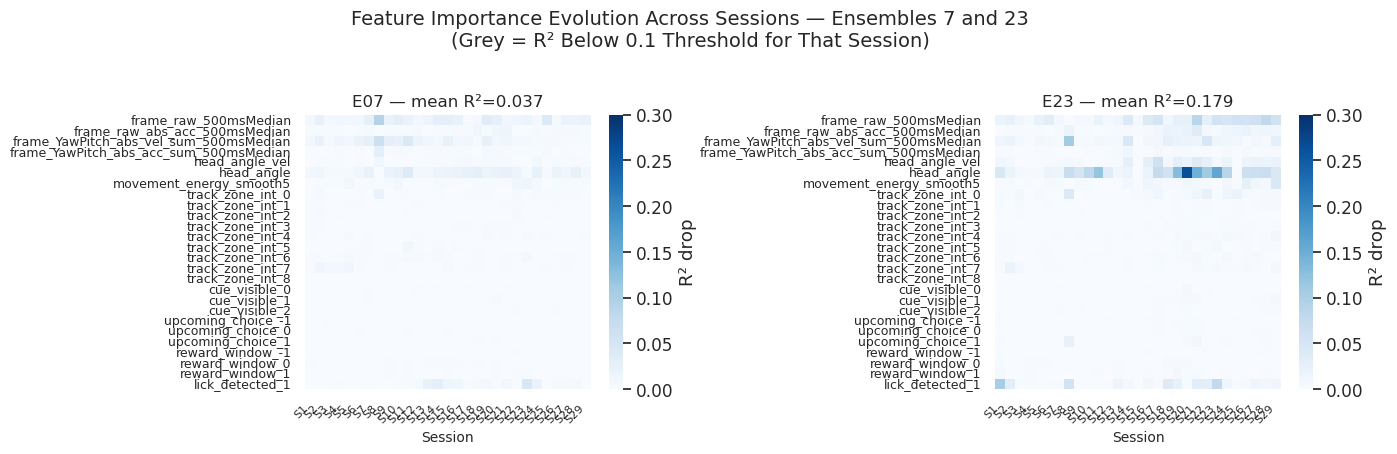

In [92]:
# ── Feature importance across sessions — ensembles 8 and 23 only ────────
focus_neurons = [6, 22]  # 0-based indices for ensembles 8 and 23
NO_DATA_COLOR = '#bbbbbb'
ncols = min(2, len(focus_neurons))
nrows = (len(focus_neurons) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 7, nrows * 4.5),
                          squeeze=False)
axes_flat = axes.flatten()

for k, n_idx in enumerate(focus_neurons):
    ax = axes_flat[k]
    imp = importance_masked[:, n_idx, :].T   # (n_feats, n_sessions)

    cmap_i = plt.cm.Blues.copy()
    cmap_i.set_bad(NO_DATA_COLOR)

    sns.heatmap(imp, ax=ax, cmap=cmap_i, vmin=0, vmax=0.3,
                xticklabels=[f"S{s+1}" for s in range(num_sessions)],
                yticklabels=all_feat_cols,
                cbar_kws={'label': 'R² drop'})
    for j in range(num_sessions):
        if np.all(np.isnan(imp[:, j])):
            ax.add_patch(plt.Rectangle([j, 0], 1, len(all_feat_cols),
                                        fill=True, facecolor=NO_DATA_COLOR,
                                        hatch='////', edgecolor='#888888', lw=0.5, zorder=2))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
    ax.set_title(f"{prefix_name}{n_idx+1:02d} — mean R²={_nm[n_idx]:.3f}", fontsize=12)
    ax.set_xlabel('Session', fontsize=10)

for k in range(len(focus_neurons), len(axes_flat)):
    axes_flat[k].set_visible(False)

plt.suptitle(
    'Feature Importance Evolution Across Sessions — Ensembles 7 and 23\n'
    f'(Grey = R² Below {R2_THRESHOLD} Threshold for That Session)',
    fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
